In [4]:
import os
from pathlib import Path

ROOT_DIR_BRAINTREEBANK = Path(r"C:\Users\simon\PyCharmMiscProject\neuroprobe-dev\braintreebank")
os.environ["ROOT_DIR_BRAINTREEBANK"] = str(ROOT_DIR_BRAINTREEBANK)

assert ROOT_DIR_BRAINTREEBANK.exists(), ROOT_DIR_BRAINTREEBANK

In [5]:
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import neuroprobe
from neuroprobe import (
    BrainTreebankSubject,
    BrainTreebankSubjectTrialBenchmarkDataset,
    generate_splits_cross_session,
    generate_splits_cross_subject,
    generate_splits_within_session,
)

In [6]:
import neuroprobe.config as neuroprobe_config

print("BrainTreebank root:", ROOT_DIR_BRAINTREEBANK)
print("Neuroprobe ROOT_DIR:", neuroprobe_config.ROOT_DIR)
print("Sampling rate:", neuroprobe_config.SAMPLING_RATE, "Hz")

# Subject setup
subject_id = 1
trial_id = 1
coordinates_type = "mni"  # "mni", "mni305", "cortical", "lpi"

subject = BrainTreebankSubject(
    subject_id=subject_id,
    allow_corrupted=False,
    cache=True,
    dtype=torch.float32,
    coordinates_type=coordinates_type,
)
print("Loaded subject", subject_id)
print("First 10 electrode labels:", subject.electrode_labels[:10])
print("First 10 electrode MNI coordinates:")
print(subject.get_electrode_coordinates()[:10])

# Benchmark dataset setup
eval_name = "volume"
output_indices = False
start_neural_data_before_word_onset = 0
end_neural_data_after_word_onset = neuroprobe_config.SAMPLING_RATE * 1  # 1 second

benchmark_dataset = BrainTreebankSubjectTrialBenchmarkDataset(
    subject,
    trial_id,
    dtype=torch.float32,
    eval_name=eval_name,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True,
)

data_electrode_labels = benchmark_dataset.electrode_labels
data_electrode_coordinates = benchmark_dataset.electrode_coordinates

print("Dataset type:", type(benchmark_dataset))
print("Dataset length:", len(benchmark_dataset))

first_item = benchmark_dataset[0]
print("First item type:", type(first_item))
print("First item:", first_item)

if isinstance(first_item, dict):
    print("First item data shape:", first_item["data"].shape)
    print("First item label:", first_item["label"])
else:
    print("First item shape:", first_item[0].shape)
    print("First item label:", first_item[1])

print("Number of electrodes in dataset:", len(data_electrode_labels))

BrainTreebank root: C:\Users\simon\PyCharmMiscProject\neuroprobe-dev\braintreebank
Neuroprobe ROOT_DIR: C:\Users\simon\PyCharmMiscProject\neuroprobe-dev\braintreebank
Sampling rate: 2048 Hz
Loaded subject 1
First 10 electrode labels: ['F3aOFa2', 'F3aOFa3', 'F3aOFa4', 'F3aOFa7', 'F3aOFa8', 'F3aOFa9', 'F3aOFa10', 'F3aOFa11', 'F3aOFa12', 'F3aOFa13']
First 10 electrode MNI coordinates:
tensor([[  8.0828,  44.3820, -15.1744],
        [ 12.4152,  43.6956, -14.8598],
        [ 15.7043,  42.0086, -13.4021],
        [ 27.5911,  38.1577,  -9.0090],
        [ 30.7824,  37.5062,  -7.6428],
        [ 35.1301,  35.9065,  -6.1294],
        [ 38.4192,  34.2195,  -4.6717],
        [ 42.6692,  33.6553,  -3.2497],
        [ 45.9583,  31.9683,  -1.7920],
        [ 50.2907,  31.2818,  -1.4774]])
Dataset type: <class 'neuroprobe.datasets.BrainTreebankSubjectTrialBenchmarkDataset'>
Dataset length: 3500
First item type: <class 'dict'>
First item: {'data': tensor([[ 32.9645,  27.3818,  20.4699,  ...,   2.1267,

In [5]:
import neuroprobe.train_test_splits as neuroprobe_train_test_splits

folds = neuroprobe_train_test_splits.generate_splits_within_session(
    subject,
    trial_id,
    eval_name,
    dtype=torch.float32,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True,
)

fold_idx = 0
fold = folds[fold_idx]
train_dataset = fold["train_dataset"]
test_dataset = fold["test_dataset"]

def dataset_to_features(ds):
    X_rows = []
    y_rows = []
    for item in ds:
        # item is a dict: {'data': ..., 'label': ..., ...}
        if isinstance(item, dict):
            x = item["data"]
            y = item["label"]
        else:
            x = item[0]
            y = item[1]

        x_np = x.numpy() if torch.is_tensor(x) else np.asarray(x)  # (n_electrodes, n_samples)

        # Summary features per electrode
        mean_per_electrode = x_np.mean(axis=1)   # shape: (n_electrodes,)
        std_per_electrode = x_np.std(axis=1)    # shape: (n_electrodes,)
        max_per_electrode = x_np.max(axis=1)    # shape: (n_electrodes,)

        features = np.concatenate([
            mean_per_electrode,
            std_per_electrode,
            max_per_electrode,
        ])  # shape: (3 * n_electrodes,)

        X_rows.append(features)
        y_rows.append(float(y))

    X = np.stack(X_rows)               # (n_examples, 3 * n_electrodes)
    y = np.array(y_rows, dtype=np.float32)
    return X, y

X_train, y_train = dataset_to_features(train_dataset)
X_test, y_test = dataset_to_features(test_dataset)

print("Compressed X_train shape:", X_train.shape)
print("Compressed X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Compressed X_train shape: (1750, 360)
Compressed X_test shape: (875, 360)
y_train shape: (1750,)
y_test shape: (875,)


In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

alphas = np.logspace(-2, 3, 6)

ridge_cv = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("ridge", RidgeCV(alphas=alphas)),
    ]
)

ridge_cv.fit(X_train, y_train)
best_alpha = ridge_cv.named_steps["ridge"].alpha_
print("Best alpha:", best_alpha)

y_train_pred = ridge_cv.predict(X_train)
y_test_pred = ridge_cv.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train R^2 (compressed): {train_r2:.3f}")
print(f"Test R^2 (compressed):  {test_r2:.3f}")

It's almost obvious the no linear model will be able to make any significant progress. Let's jump right to a baseline CNN. Basically this is a classic high-variance problem, there's no way a linear model will perform well.

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class NeuroprobeTorchDataset(Dataset):
    def __init__(self, ds):
        self.ds = ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]

        if isinstance(item, dict):
            x = item["data"]
            y = item["label"]
        else:
            x = item[0]
            y = item[1]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        else:
            x = x.to(torch.float32)

        y = torch.tensor(float(y), dtype=torch.float32)
        return x, y


train_torch_ds = NeuroprobeTorchDataset(train_dataset)
test_torch_ds = NeuroprobeTorchDataset(test_dataset)

train_loader = DataLoader(train_torch_ds, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_torch_ds, batch_size=16, shuffle=False, num_workers=0)

sample_x, sample_y = train_torch_ds[0]
print("Sample x shape:", sample_x.shape)  # (n_electrodes, time)
print("Sample y:", sample_y)

In [ ]:
class EEGCNNRegressor(nn.Module):
    def __init__(self, n_electrodes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_electrodes, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x.squeeze(-1)


n_electrodes = sample_x.shape[0]
model = EEGCNNRegressor(n_electrodes=n_electrodes).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)  # shape: (batch, n_electrodes, time)
        y = y.to(device)

        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_y = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        preds = model(x)
        loss = criterion(preds, y)

        total_loss += loss.item() * x.size(0)
        all_y.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)
    r2 = r2_score(y_true, y_pred)

    return total_loss / len(loader.dataset), r2, y_true, y_pred

In [ ]:
num_epochs = 10

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test R^2: {test_r2:.4f}"
    )

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)
plt.xlabel("True volume")
plt.ylabel("Predicted volume")
plt.title("CNN regression on Neuroprobe volume")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.tight_layout()
plt.show()

The basic CNN is still worse than using the mean. I'm going to try these new changes:
1: reduce channels 64 --> 32 as it's obviously overfitting
2: Increase wieght decay
3: add early stopping
4: add an embedding per electrode and add time-series

In [ ]:
class ElectrodeEmbeddingCNNRegressor(nn.Module):
    def __init__(self, n_electrodes, emb_dim=16, hidden_channels=32):
        super().__init__()

        self.n_electrodes = n_electrodes
        self.emb_dim = emb_dim

        # Learn one embedding vector per electrode
        self.electrode_embedding = nn.Embedding(n_electrodes, emb_dim)

        # Turn each embedding into a scalar gate for that electrode
        self.electrode_gate = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, 1),
            nn.Sigmoid(),
        )

        # Small temporal CNN
        self.temporal_net = nn.Sequential(
            nn.Conv1d(n_electrodes, hidden_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(hidden_channels, hidden_channels * 2, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels * 2),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: (batch, n_electrodes, time)
        batch_size = x.shape[0]
        device = x.device

        electrode_ids = torch.arange(self.n_electrodes, device=device)  # (n_electrodes,)
        emb = self.electrode_embedding(electrode_ids)  # (n_electrodes, emb_dim)
        gates = self.electrode_gate(emb).squeeze(-1)  # (n_electrodes,)
        gates = gates.view(1, self.n_electrodes, 1)  # (1, n_electrodes, 1)

        # Electrode-specific scaling
        x = x * gates

        x = self.temporal_net(x)
        x = self.regressor(x)
        return x.squeeze(-1)

In [ ]:
n_electrodes = sample_x.shape[0]
model = ElectrodeEmbeddingCNNRegressor(
    n_electrodes=n_electrodes,
    emb_dim=16,
    hidden_channels=32,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-3)

print(model)

In [ ]:
num_epochs = 50
best_test_r2 = -np.inf
best_state_dict = None
history = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "test_r2": test_r2,
    })

    if test_r2 > best_test_r2:
        best_test_r2 = test_r2
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test R^2: {test_r2:.4f} | "
        f"Best Test R^2: {best_test_r2:.4f}"
    )

In [ ]:
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

test_loss, test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)
print(f"Restored best model | Test Loss: {test_loss:.4f} | Test R^2: {test_r2:.4f}")

In [ ]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=history_df, x="epoch", y="train_loss", ax=axes[0], label="Train Loss")
sns.lineplot(data=history_df, x="epoch", y="test_loss", ax=axes[0], label="Test Loss")
axes[0].set_title("Loss curves")

sns.lineplot(data=history_df, x="epoch", y="test_r2", ax=axes[1])
axes[1].axhline(0.0, color="red", linestyle="--")
axes[1].set_title("Test R^2")
axes[1].set_ylabel("R^2")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)
plt.xlabel("True volume")
plt.ylabel("Predicted volume")
plt.title("Electrode-embedding CNN on Neuroprobe volume")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.tight_layout()
plt.show()

# New Changes
Run all within-session folds, not just fold_idx = 0.

Replace the pure channel-CNN with an electrode-token model:

per-electrode temporal encoder,

coordinate embedding,

learned electrode embedding,

optional subject embedding,

self-attention across electrodes.

Speed up training by preloading tensors, using more DataLoader workers if stable, and keeping the model compact.

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class NeuroprobeTorchDataset(Dataset):
    def __init__(self, ds, subject_id):
        self.ds = ds
        self.subject_id = subject_id

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]

        if isinstance(item, dict):
            x = item["data"]
            y = item["label"]
        else:
            x = item[0]
            y = item[1]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        else:
            x = x.to(torch.float32)

        y = torch.tensor(float(y), dtype=torch.float32)
        subject_idx = torch.tensor(self.subject_id, dtype=torch.long)
        return x, y, subject_idx

In [ ]:
class ElectrodeTokenTransformerRegressor(nn.Module):
    def __init__(
            self,
            n_electrodes,
            electrode_coordinates,
            num_subjects,
            time_emb_dim=32,
            coord_emb_dim=16,
            electrode_emb_dim=16,
            subject_emb_dim=8,
            model_dim=64,
            num_heads=4,
            num_layers=2,
            dropout=0.2,
    ):
        super().__init__()

        self.n_electrodes = n_electrodes

        coord_tensor = torch.as_tensor(
            electrode_coordinates, dtype=torch.float32
        ).clone().detach()
        self.register_buffer("electrode_coordinates", coord_tensor)

        self.time_encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, time_emb_dim, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.coord_mlp = nn.Sequential(
            nn.Linear(3, coord_emb_dim),
            nn.LayerNorm(coord_emb_dim),
            nn.ReLU(),
        )

        self.electrode_embedding = nn.Embedding(n_electrodes, electrode_emb_dim)
        self.subject_embedding = nn.Embedding(num_subjects, subject_emb_dim)

        fused_dim = time_emb_dim + coord_emb_dim + electrode_emb_dim + subject_emb_dim

        self.token_projection = nn.Sequential(
            nn.Linear(fused_dim, model_dim),
            nn.LayerNorm(model_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=model_dim * 2,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False,
        )

        self.regressor = nn.Sequential(
            nn.Linear(model_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, subject_idx):
        batch_size, n_electrodes, time_len = x.shape
        device = x.device

        x = x.view(batch_size * n_electrodes, 1, time_len)
        time_features = self.time_encoder(x).squeeze(-1)
        time_features = time_features.view(batch_size, n_electrodes, -1)

        coords = self.electrode_coordinates.to(device)
        coord_features = self.coord_mlp(coords)
        coord_features = coord_features.unsqueeze(0).expand(batch_size, -1, -1)

        electrode_ids = torch.arange(n_electrodes, device=device)
        electrode_features = self.electrode_embedding(electrode_ids)
        electrode_features = electrode_features.unsqueeze(0).expand(batch_size, -1, -1)

        subject_features = self.subject_embedding(subject_idx)
        subject_features = subject_features.unsqueeze(1).expand(-1, n_electrodes, -1)

        tokens = torch.cat(
            [time_features, coord_features, electrode_features, subject_features],
            dim=-1,
        )

        tokens = self.token_projection(tokens)
        tokens = self.transformer(tokens)

        pooled = tokens.mean(dim=1)
        out = self.regressor(pooled)
        return out.squeeze(-1)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x, y, subject_idx in loader:
        x = x.to(device)
        y = y.to(device)
        subject_idx = subject_idx.to(device)

        optimizer.zero_grad()
        preds = model(x, subject_idx)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_y = []
    all_preds = []

    for x, y, subject_idx in loader:
        x = x.to(device)
        y = y.to(device)
        subject_idx = subject_idx.to(device)

        preds = model(x, subject_idx)
        loss = criterion(preds, y)

        total_loss += loss.item() * x.size(0)
        all_y.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)
    r2 = r2_score(y_true, y_pred)

    return total_loss / len(loader.dataset), r2, y_true, y_pred

In [ ]:
import neuroprobe.train_test_splits as neuroprobe_train_test_splits

all_fold_results = []

folds = neuroprobe_train_test_splits.generate_splits_within_session(
    subject,
    trial_id,
    eval_name,
    dtype=torch.float32,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True,
)

for fold_idx, fold in enumerate(folds):
    print(f"\n===== Fold {fold_idx} =====")

    train_dataset = fold["train_dataset"]
    test_dataset = fold["test_dataset"]

    train_torch_ds = NeuroprobeTorchDataset(train_dataset, subject_id=0)
    test_torch_ds = NeuroprobeTorchDataset(test_dataset, subject_id=0)

    train_loader = DataLoader(
        train_torch_ds,
        batch_size=32,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_torch_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    sample_x, sample_y, sample_subject = train_torch_ds[0]
    n_electrodes = sample_x.shape[0]

    model = ElectrodeTokenTransformerRegressor(
        n_electrodes=n_electrodes,
        electrode_coordinates=data_electrode_coordinates,
        num_subjects=1,
        time_emb_dim=32,
        coord_emb_dim=16,
        electrode_emb_dim=16,
        subject_emb_dim=8,
        model_dim=64,
        num_heads=4,
        num_layers=2,
        dropout=0.2,
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

    num_epochs = 25
    patience = 6
    best_test_r2 = -np.inf
    best_state_dict = None
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)

        improved = test_r2 > best_test_r2
        if improved:
            best_test_r2 = test_r2
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Fold {fold_idx} | Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test R^2: {test_r2:.4f} | "
            f"Best: {best_test_r2:.4f}"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping on fold {fold_idx} at epoch {epoch}")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    final_test_loss, final_test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    all_fold_results.append({
        "fold_idx": fold_idx,
        "best_test_r2": best_test_r2,
        "final_test_r2": final_test_r2,
        "final_test_loss": final_test_loss,
    })

fold_results_df = pd.DataFrame(all_fold_results)
print(fold_results_df)
print("Mean best R^2 across folds:", fold_results_df["best_test_r2"].mean())
print("Std best R^2 across folds:", fold_results_df["best_test_r2"].std())

===== Fold 0 =====
Fold 0 | Epoch 01 | Train Loss: 0.2756 | Test Loss: 0.2527 | Test R^2: -0.0109 | Best: -0.0109
Fold 0 | Epoch 02 | Train Loss: 0.2536 | Test Loss: 0.2538 | Test R^2: -0.0151 | Best: -0.0109
Fold 0 | Epoch 03 | Train Loss: 0.2505 | Test Loss: 0.2561 | Test R^2: -0.0245 | Best: -0.0109
Fold 0 | Epoch 04 | Train Loss: 0.2434 | Test Loss: 0.2553 | Test R^2: -0.0211 | Best: -0.0109
Fold 0 | Epoch 05 | Train Loss: 0.2302 | Test Loss: 0.2737 | Test R^2: -0.0948 | Best: -0.0109

Obviously going nowhere.

Let's try changing the metrics

In [ ]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, roc_auc_score
import neuroprobe.train_test_splits as neuroprobe_train_test_splits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

REGRESSION_TASKS = {
    "volume",
    "delta_volume",
    "pitch",
    "gpt2_surprisal",
    "word_gap",
    "word_index",
    "word_head_pos",
    "word_length",
}
CLASSIFICATION_TASKS = {
    "speech",
    "onset",
    "face_num",
    "frame_brightness",
    "global_flow",
    "local_flow",
    "word_part_speech",
}

# Smoke test: just these two first
TASKS_TO_RUN = ["pitch", "speech"]


class NeuroprobeTorchDataset(Dataset):
    def __init__(self, ds, subject_id, task_name):
        self.ds = ds
        self.subject_id = subject_id
        self.task_name = task_name

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        if isinstance(item, dict):
            x = item["data"]
            y = item["label"]
        else:
            x, y = item[0], item[1]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        else:
            x = x.to(torch.float32)

        # Both regression and classification use float labels here;
        # classification will go into BCEWithLogitsLoss.
        y = torch.tensor(float(y), dtype=torch.float32)

        subject_idx = torch.tensor(self.subject_id, dtype=torch.long)
        return x, y, subject_idx


class ElectrodeTokenTransformerRegressor(nn.Module):
    def __init__(
        self,
        n_electrodes,
        electrode_coordinates,
        num_subjects,
        time_emb_dim=32,
        coord_emb_dim=16,
        electrode_emb_dim=16,
        subject_emb_dim=8,
        model_dim=64,
        num_heads=4,
        num_layers=2,
        dropout=0.2,
    ):
        super().__init__()
        self.n_electrodes = n_electrodes

        coord_tensor = torch.as_tensor(
            electrode_coordinates, dtype=torch.float32
        ).clone().detach()
        self.register_buffer("electrode_coordinates", coord_tensor)

        self.time_encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, time_emb_dim, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.coord_mlp = nn.Sequential(
            nn.Linear(3, coord_emb_dim),
            nn.LayerNorm(coord_emb_dim),
            nn.ReLU(),
        )

        self.electrode_embedding = nn.Embedding(n_electrodes, electrode_emb_dim)
        self.subject_embedding = nn.Embedding(num_subjects, subject_emb_dim)

        fused_dim = (
            time_emb_dim + coord_emb_dim + electrode_emb_dim + subject_emb_dim
        )

        self.token_projection = nn.Sequential(
            nn.Linear(fused_dim, model_dim),
            nn.LayerNorm(model_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=model_dim * 2,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False,
        )

        self.head = nn.Sequential(
            nn.Linear(model_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, subject_idx):
        batch_size, n_electrodes, time_len = x.shape
        device = x.device

        x = x.view(batch_size * n_electrodes, 1, time_len)
        time_features = self.time_encoder(x).squeeze(-1)
        time_features = time_features.view(batch_size, n_electrodes, -1)

        coords = self.electrode_coordinates.to(device)
        coord_features = self.coord_mlp(coords).unsqueeze(0).expand(
            batch_size, -1, -1
        )

        electrode_ids = torch.arange(n_electrodes, device=device)
        electrode_features = self.electrode_embedding(electrode_ids).unsqueeze(
            0
        ).expand(batch_size, -1, -1)

        subject_features = self.subject_embedding(subject_idx).unsqueeze(
            1
        ).expand(-1, n_electrodes, -1)

        tokens = torch.cat(
            [time_features, coord_features, electrode_features, subject_features],
            dim=-1,
        )

        tokens = self.token_projection(tokens)
        tokens = self.transformer(tokens)
        pooled = tokens.mean(dim=1)
        return self.head(pooled).squeeze(-1)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x, y, subject_idx in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        subject_idx = subject_idx.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(x, subject_idx)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_regression(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_y, all_preds = [], []

    for x, y, subject_idx in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        subject_idx = subject_idx.to(device, non_blocking=True)

        preds = model(x, subject_idx)
        loss = criterion(preds, y)

        total_loss += loss.item() * x.size(0)
        all_y.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)

    model_metric = r2_score(y_true, y_pred)

    baseline_pred = np.full_like(y_true, fill_value=y_true.mean())
    baseline_metric = r2_score(y_true, baseline_pred)

    return {
        "loss": total_loss / len(loader.dataset),
        "metric_name": "r2",
        "metric": model_metric,
        "baseline_metric": baseline_metric,
    }


@torch.no_grad()
def evaluate_classification(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_y, all_logits = [], []

    for x, y, subject_idx in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        subject_idx = subject_idx.to(device, non_blocking=True)

        logits = model(x, subject_idx)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        all_y.append(y.cpu().numpy())
        all_logits.append(logits.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_score = np.concatenate(all_logits)

    if len(np.unique(y_true)) < 2:
        model_metric = np.nan
        baseline_metric = 0.5
    else:
        model_metric = roc_auc_score(y_true, y_score)
        baseline_metric = 0.5

    return {
        "loss": total_loss / len(loader.dataset),
        "metric_name": "auroc",
        "metric": model_metric,
        "baseline_metric": baseline_metric,
    }


def run_task(task_name, num_epochs=5, patience=2, batch_size=32):
    print(f"\n================ TASK: {task_name} ================")

    folds = neuroprobe_train_test_splits.generate_splits_within_session(
        subject,
        trial_id,
        task_name,
        dtype=torch.float32,
        output_indices=output_indices,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True,
    )

    task_results = []

    for fold_idx, fold in enumerate(folds):
        print(f"\n----- Fold {fold_idx} -----")
        train_dataset = fold["train_dataset"]
        test_dataset = fold["test_dataset"]

        train_torch_ds = NeuroprobeTorchDataset(
            train_dataset, subject_id=0, task_name=task_name
        )
        test_torch_ds = NeuroprobeTorchDataset(
            test_dataset, subject_id=0, task_name=task_name
        )

        train_loader = DataLoader(
            train_torch_ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )
        test_loader = DataLoader(
            test_torch_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

        sample_x, _, _ = train_torch_ds[0]
        n_electrodes = sample_x.shape[0]

        model = ElectrodeTokenTransformerRegressor(
            n_electrodes=n_electrodes,
            electrode_coordinates=data_electrode_coordinates,
            num_subjects=1,
            time_emb_dim=32,
            coord_emb_dim=16,
            electrode_emb_dim=16,
            subject_emb_dim=8,
            model_dim=64,
            num_heads=4,
            num_layers=2,
            dropout=0.2,
        ).to(device)

        is_classification = task_name in CLASSIFICATION_TASKS
        criterion = nn.BCEWithLogitsLoss() if is_classification else nn.MSELoss()
        # Smaller lr for stability in smoke tests
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=3e-5, weight_decay=1e-3
        )

        best_metric = -np.inf
        best_state_dict = None
        epochs_without_improvement = 0

        for epoch in range(1, num_epochs + 1):
            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion, device
            )

            if is_classification:
                eval_out = evaluate_classification(
                    model, test_loader, criterion, device
                )
            else:
                eval_out = evaluate_regression(
                    model, test_loader, criterion, device
                )

            improved = eval_out["metric"] > best_metric
            if improved:
                best_metric = eval_out["metric"]
                best_state_dict = copy.deepcopy(model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            print(
                f"Fold {fold_idx} | Epoch {epoch:02d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Test Loss: {eval_out['loss']:.4f} | "
                f"{eval_out['metric_name']}: {eval_out['metric']:.4f} | "
                f"Baseline: {eval_out['baseline_metric']:.4f} | "
                f"Best: {best_metric:.4f}"
            )

            if epochs_without_improvement >= patience:
                print(f"Early stopping on fold {fold_idx} at epoch {epoch}")
                break

        if best_state_dict is not None:
            model.load_state_dict(best_state_dict)

        if is_classification:
            final_eval = evaluate_classification(
                model, test_loader, criterion, device
            )
        else:
            final_eval = evaluate_regression(
                model, test_loader, criterion, device
            )

        task_results.append(
            {
                "task": task_name,
                "fold_idx": fold_idx,
                "metric_name": final_eval["metric_name"],
                "best_metric": best_metric,
                "final_metric": final_eval["metric"],
                "baseline_metric": final_eval["baseline_metric"],
                "final_loss": final_eval["loss"],
            }
        )

    return pd.DataFrame(task_results)


all_results = []
for task_name in TASKS_TO_RUN:
    df_task = run_task(task_name, num_epochs=5, patience=2, batch_size=32)
    all_results.append(df_task)

results_df = pd.concat(all_results, ignore_index=True)

summary_df = (
    results_df.groupby(["task", "metric_name"], as_index=False)
    .agg(
        mean_best_metric=("best_metric", "mean"),
        std_best_metric=("best_metric", "std"),
        mean_final_metric=("final_metric", "mean"),
        mean_baseline_metric=("baseline_metric", "mean"),
    )
    .sort_values(["metric_name", "mean_best_metric"], ascending=[True, False])
)

print("\nPer-fold results:")
print(results_df)

print("\nSummary:")
print(summary_df)

Let's implement my intuition here

In [6]:
import copy
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, roc_auc_score
import neuroprobe.train_test_splits as neuroprobe_train_test_splits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

TASKS = ["delta_volume", "speech", "pitch", "gpt2_surprisal", "word_gap"]
REGRESSION_TASKS = {"volume", "delta_volume", "pitch", "gpt2_surprisal", "word_gap"}
CLASSIFICATION_TASKS = {"speech"}

DEBUG_FOLD_ONLY = 0
BATCH_SIZE = 32
NUM_EPOCHS = 8
PATIENCE = 3
BASE_LR = 3e-4
MIN_LR_MULT = 0.2
MAX_LR_MULT = 3.0
LR_DOWN = 0.6
LR_UP = 1.08
LOSS_DELTA_EPS = 1e-3
WEIGHT_DECAY = 1e-3


class NeuroprobeTaskDataset(Dataset):
    def __init__(self, ds, subject_id=0):
        self.ds = ds
        self.subject_id = subject_id

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        if isinstance(item, dict):
            x = item["data"]
            y = item["label"]
        else:
            x, y = item[0], item[1]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        else:
            x = x.to(torch.float32)

        y = torch.tensor(float(y), dtype=torch.float32)
        subject_idx = torch.tensor(self.subject_id, dtype=torch.long)
        return x, y, subject_idx


class SharedElectrodeCNNEncoder(nn.Module):
    def __init__(
            self,
            n_electrodes,
            electrode_coordinates,
            num_subjects=1,
            coord_dim=8,
            electrode_emb_dim=8,
            subject_emb_dim=4,
            hidden_channels=16,
            proj_dim=64,
            dropout=0.2,
    ):
        super().__init__()
        self.n_electrodes = n_electrodes

        coord_tensor = torch.as_tensor(
            electrode_coordinates, dtype=torch.float32
        ).clone().detach()
        self.register_buffer("electrode_coordinates", coord_tensor)

        self.coord_mlp = nn.Sequential(
            nn.Linear(3, coord_dim),
            nn.LayerNorm(coord_dim),
            nn.ReLU(),
        )
        self.electrode_embedding = nn.Embedding(n_electrodes, electrode_emb_dim)
        self.subject_embedding = nn.Embedding(num_subjects, subject_emb_dim)

        self.electrode_gate = nn.Sequential(
            nn.Linear(coord_dim + electrode_emb_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

        self.temporal_cnn = nn.Sequential(
            nn.Conv1d(n_electrodes, hidden_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(hidden_channels, hidden_channels * 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_channels * 2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(hidden_channels * 2, hidden_channels * 4, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels * 4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        cnn_out_dim = hidden_channels * 4
        meta_dim = coord_dim + electrode_emb_dim + subject_emb_dim

        self.proj = nn.Sequential(
            nn.Linear(cnn_out_dim + meta_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x, subject_idx):
        batch_size, n_electrodes, _ = x.shape
        device = x.device

        coords = self.electrode_coordinates.to(device)
        coord_features = self.coord_mlp(coords)

        electrode_ids = torch.arange(n_electrodes, device=device)
        electrode_features = self.electrode_embedding(electrode_ids)

        gate_in = torch.cat([coord_features, electrode_features], dim=-1)
        gates = self.electrode_gate(gate_in).squeeze(-1).view(1, n_electrodes, 1)

        x = x * gates
        cnn_feat = self.temporal_cnn(x).squeeze(-1)

        pooled_coord = coord_features.mean(dim=0, keepdim=True).expand(batch_size, -1)
        pooled_elec = electrode_features.mean(dim=0, keepdim=True).expand(batch_size, -1)
        subj_feat = self.subject_embedding(subject_idx)

        combined = torch.cat([cnn_feat, pooled_coord, pooled_elec, subj_feat], dim=-1)
        z = self.proj(combined)
        return z


class MultiTaskBrainCNN(nn.Module):
    def __init__(self, n_electrodes, electrode_coordinates, num_subjects=1, dropout=0.2):
        super().__init__()
        self.encoder = SharedElectrodeCNNEncoder(
            n_electrodes=n_electrodes,
            electrode_coordinates=electrode_coordinates,
            num_subjects=num_subjects,
            coord_dim=8,
            electrode_emb_dim=8,
            subject_emb_dim=4,
            hidden_channels=16,
            proj_dim=64,
            dropout=dropout,
        )

        self.heads = nn.ModuleDict({
            "delta_volume": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
            "speech": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
            "pitch": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
            "gpt2_surprisal": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
            "word_gap": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
        })

    def forward(self, x, subject_idx, task_name):
        z = self.encoder(x, subject_idx)
        out = self.heads[task_name](z).squeeze(-1)
        return out


def set_optimizer_lr(optimizer, lr):
    for pg in optimizer.param_groups:
        pg["lr"] = lr


def train_one_task_epoch(model, loader, optimizer, criterion, device, task_name):
    model.train()
    total_loss = 0.0
    n_examples = 0

    for x, y, subject_idx in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        subject_idx = subject_idx.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(x, subject_idx, task_name)
        loss = criterion(preds, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n_examples += x.size(0)

    return total_loss / max(n_examples, 1)


@torch.no_grad()
def evaluate_task(model, loader, criterion, device, task_name):
    model.eval()
    total_loss = 0.0
    all_y, all_preds = [], []

    for x, y, subject_idx in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        subject_idx = subject_idx.to(device, non_blocking=True)

        preds = model(x, subject_idx, task_name)
        loss = criterion(preds, y)

        total_loss += loss.item() * x.size(0)
        all_y.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)

    if task_name in CLASSIFICATION_TASKS:
        if len(np.unique(y_true)) < 2:
            metric = np.nan
        else:
            metric = roc_auc_score(y_true, y_pred)
        metric_name = "auroc"
        baseline_metric = 0.5
    else:
        metric = r2_score(y_true, y_pred)
        baseline_pred = np.full_like(y_true, fill_value=y_true.mean())
        baseline_metric = r2_score(y_true, baseline_pred)
        metric_name = "r2"

    return {
        "loss": total_loss / len(loader.dataset),
        "metric_name": metric_name,
        "metric": metric,
        "baseline_metric": baseline_metric,
    }


folds_by_task = {}
for task_name in TASKS:
    folds_by_task[task_name] = neuroprobe_train_test_splits.generate_splits_within_session(
        subject,
        trial_id,
        task_name,
        dtype=torch.float32,
        output_indices=output_indices,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True,
    )

fold_idx = DEBUG_FOLD_ONLY
print(f"Running multitask prototype on fold {fold_idx}")

task_train_loaders = {}
task_test_loaders = {}

for task_name in TASKS:
    fold = folds_by_task[task_name][fold_idx]
    train_dataset = fold["train_dataset"]
    test_dataset = fold["test_dataset"]

    train_torch_ds = NeuroprobeTaskDataset(train_dataset, subject_id=0)
    test_torch_ds = NeuroprobeTaskDataset(test_dataset, subject_id=0)

    task_train_loaders[task_name] = DataLoader(
        train_torch_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    task_test_loaders[task_name] = DataLoader(
        test_torch_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

sample_x, _, _ = next(iter(task_train_loaders["speech"]))
n_electrodes = sample_x.shape[1]

model = MultiTaskBrainCNN(
    n_electrodes=n_electrodes,
    electrode_coordinates=data_electrode_coordinates,
    num_subjects=1,
    dropout=0.25,
).to(device)

criteria = {
    "delta_volume": nn.MSELoss(),
    "speech": nn.BCEWithLogitsLoss(),
    "pitch": nn.MSELoss(),
    "gpt2_surprisal": nn.MSELoss(),
    "word_gap": nn.MSELoss(),
}

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BASE_LR,
    weight_decay=WEIGHT_DECAY,
)

task_lr_mult = {task: 1.0 for task in TASKS}
task_loss_history = {task: [] for task in TASKS}
best_score = -np.inf
best_state_dict = None
epochs_without_improvement = 0
history_rows = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n========== Epoch {epoch:02d} ==========")

    epoch_train_losses = {}
    epoch_eval = {}

    for task_name in TASKS:
        current_lr = BASE_LR * task_lr_mult[task_name]
        set_optimizer_lr(optimizer, current_lr)

        train_loss = train_one_task_epoch(
            model=model,
            loader=task_train_loaders[task_name],
            optimizer=optimizer,
            criterion=criteria[task_name],
            device=device,
            task_name=task_name,
        )
        epoch_train_losses[task_name] = train_loss
        task_loss_history[task_name].append(train_loss)

        eval_out = evaluate_task(
            model=model,
            loader=task_test_loaders[task_name],
            criterion=criteria[task_name],
            device=device,
            task_name=task_name,
        )
        epoch_eval[task_name] = eval_out

        print(
            f"{task_name:15s} | "
            f"lr_mult={task_lr_mult[task_name]:.3f} | "
            f"train_loss={train_loss:.4f} | "
            f"test_loss={eval_out['loss']:.4f} | "
            f"{eval_out['metric_name']}={eval_out['metric']:.4f} | "
            f"baseline={eval_out['baseline_metric']:.4f}"
        )

    # adaptive per-task LR multiplier based on loss trend
    for task_name in TASKS:
        losses = task_loss_history[task_name]
        if len(losses) >= 2:
            delta = losses[-1] - losses[-2]
            if delta > LOSS_DELTA_EPS:
                task_lr_mult[task_name] *= LR_DOWN
            elif delta < -LOSS_DELTA_EPS:
                task_lr_mult[task_name] *= LR_UP

            task_lr_mult[task_name] = float(
                np.clip(task_lr_mult[task_name], MIN_LR_MULT, MAX_LR_MULT)
            )

    # combined score: average over normalized task metrics
    normalized_scores = []
    for task_name in TASKS:
        metric = epoch_eval[task_name]["metric"]
        baseline = epoch_eval[task_name]["baseline_metric"]

        if np.isnan(metric):
            continue

        if task_name in CLASSIFICATION_TASKS:
            norm_score = metric - baseline
        else:
            norm_score = metric - baseline

        normalized_scores.append(norm_score)

    combined_score = float(np.mean(normalized_scores)) if normalized_scores else -np.inf
    print(f"Combined score: {combined_score:.4f}")

    for task_name in TASKS:
        history_rows.append({
            "epoch": epoch,
            "task": task_name,
            "lr_mult": task_lr_mult[task_name],
            "train_loss": epoch_train_losses[task_name],
            "test_loss": epoch_eval[task_name]["loss"],
            "metric_name": epoch_eval[task_name]["metric_name"],
            "metric": epoch_eval[task_name]["metric"],
            "baseline_metric": epoch_eval[task_name]["baseline_metric"],
            "combined_score": combined_score,
        })

    if combined_score > best_score:
        best_score = combined_score
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Best combined score so far: {best_score:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

final_rows = []
for task_name in TASKS:
    final_eval = evaluate_task(
        model=model,
        loader=task_test_loaders[task_name],
        criterion=criteria[task_name],
        device=device,
        task_name=task_name,
    )
    final_rows.append({
        "task": task_name,
        "metric_name": final_eval["metric_name"],
        "final_metric": final_eval["metric"],
        "baseline_metric": final_eval["baseline_metric"],
        "final_loss": final_eval["loss"],
        "final_lr_mult": task_lr_mult[task_name],
    })

history_df = pd.DataFrame(history_rows)
final_df = pd.DataFrame(final_rows)

print("\nHistory:")
print(history_df.tail(10))

print("\nFinal multitask summary:")
print(final_df)
print("\nBest combined score:", best_score)

Using device: cpu
Running multitask prototype on fold 0

========== Epoch 01 ==========
delta_volume    | lr_mult=1.000 | train_loss=0.4341 | test_loss=0.2203 | r2=0.1189 | baseline=0.0000
speech          | lr_mult=1.000 | train_loss=0.6902 | test_loss=0.6857 | auroc=0.6010 | baseline=0.5000
pitch           | lr_mult=1.000 | train_loss=0.2743 | test_loss=0.2646 | r2=-0.0585 | baseline=0.0000
gpt2_surprisal  | lr_mult=1.000 | train_loss=0.3813 | test_loss=0.2587 | r2=-0.0349 | baseline=0.0000
word_gap        | lr_mult=1.000 | train_loss=0.2938 | test_loss=0.2488 | r2=0.0049 | baseline=0.0000
Combined score: 0.0263
Best combined score so far: 0.0263

========== Epoch 02 ==========
delta_volume    | lr_mult=1.000 | train_loss=0.2448 | test_loss=0.2058 | r2=0.1767 | baseline=0.0000
speech          | lr_mult=1.000 | train_loss=0.6731 | test_loss=0.6735 | auroc=0.6259 | baseline=0.5000
pitch           | lr_mult=1.000 | train_loss=0.2570 | test_loss=0.2718 | r2=-0.0870 | baseline=0.0000
gpt2_

It's pretty evident that at this point, a CNN on it's own isn't the solution. I'm going to go back to my MITx datascience course I did a few years back and try some of the datascience techniques. See if I can create new metrics and find correlations in the data. Basically I saw the top submissions are all linear so there's obviously some merit to the idea of using these techniques. The best score I got was 0.06

Task: speech
Fold: 0
Train size: 1750
Test size: 875
X_train_raw: (1750, 120, 2048)
y_train: (1750,)
coords: (120, 3)
n_electrodes: 120
   electrode_idx electrode_label          x         y         z  global_mean  \
0              0          T1bIc1  43.651859  2.169823 -2.828815    -2.732498   
1              1          T1bIc2  45.964802  0.273297 -2.534156    -4.488721   
2              2          T1bIc3  49.336380 -1.535946 -2.183735    -3.506430   
3              3          T1bIc4  52.707958 -3.345189 -1.833313    -1.515969   
4              4          T1bIc5  55.981701 -4.118884 -1.574460    -0.573348   

   global_std  global_rms  example_mean_mean  example_mean_std  ...  \
0   49.840599   49.915447          -2.732498         30.614603  ...   
1   51.533508   51.728630          -4.488721         32.941746  ...   
2   73.623543   73.706993          -3.506430         48.854687  ...   
3   67.981094   67.997993          -1.515969         35.105881  ...   
4   74.330200   74.332413   

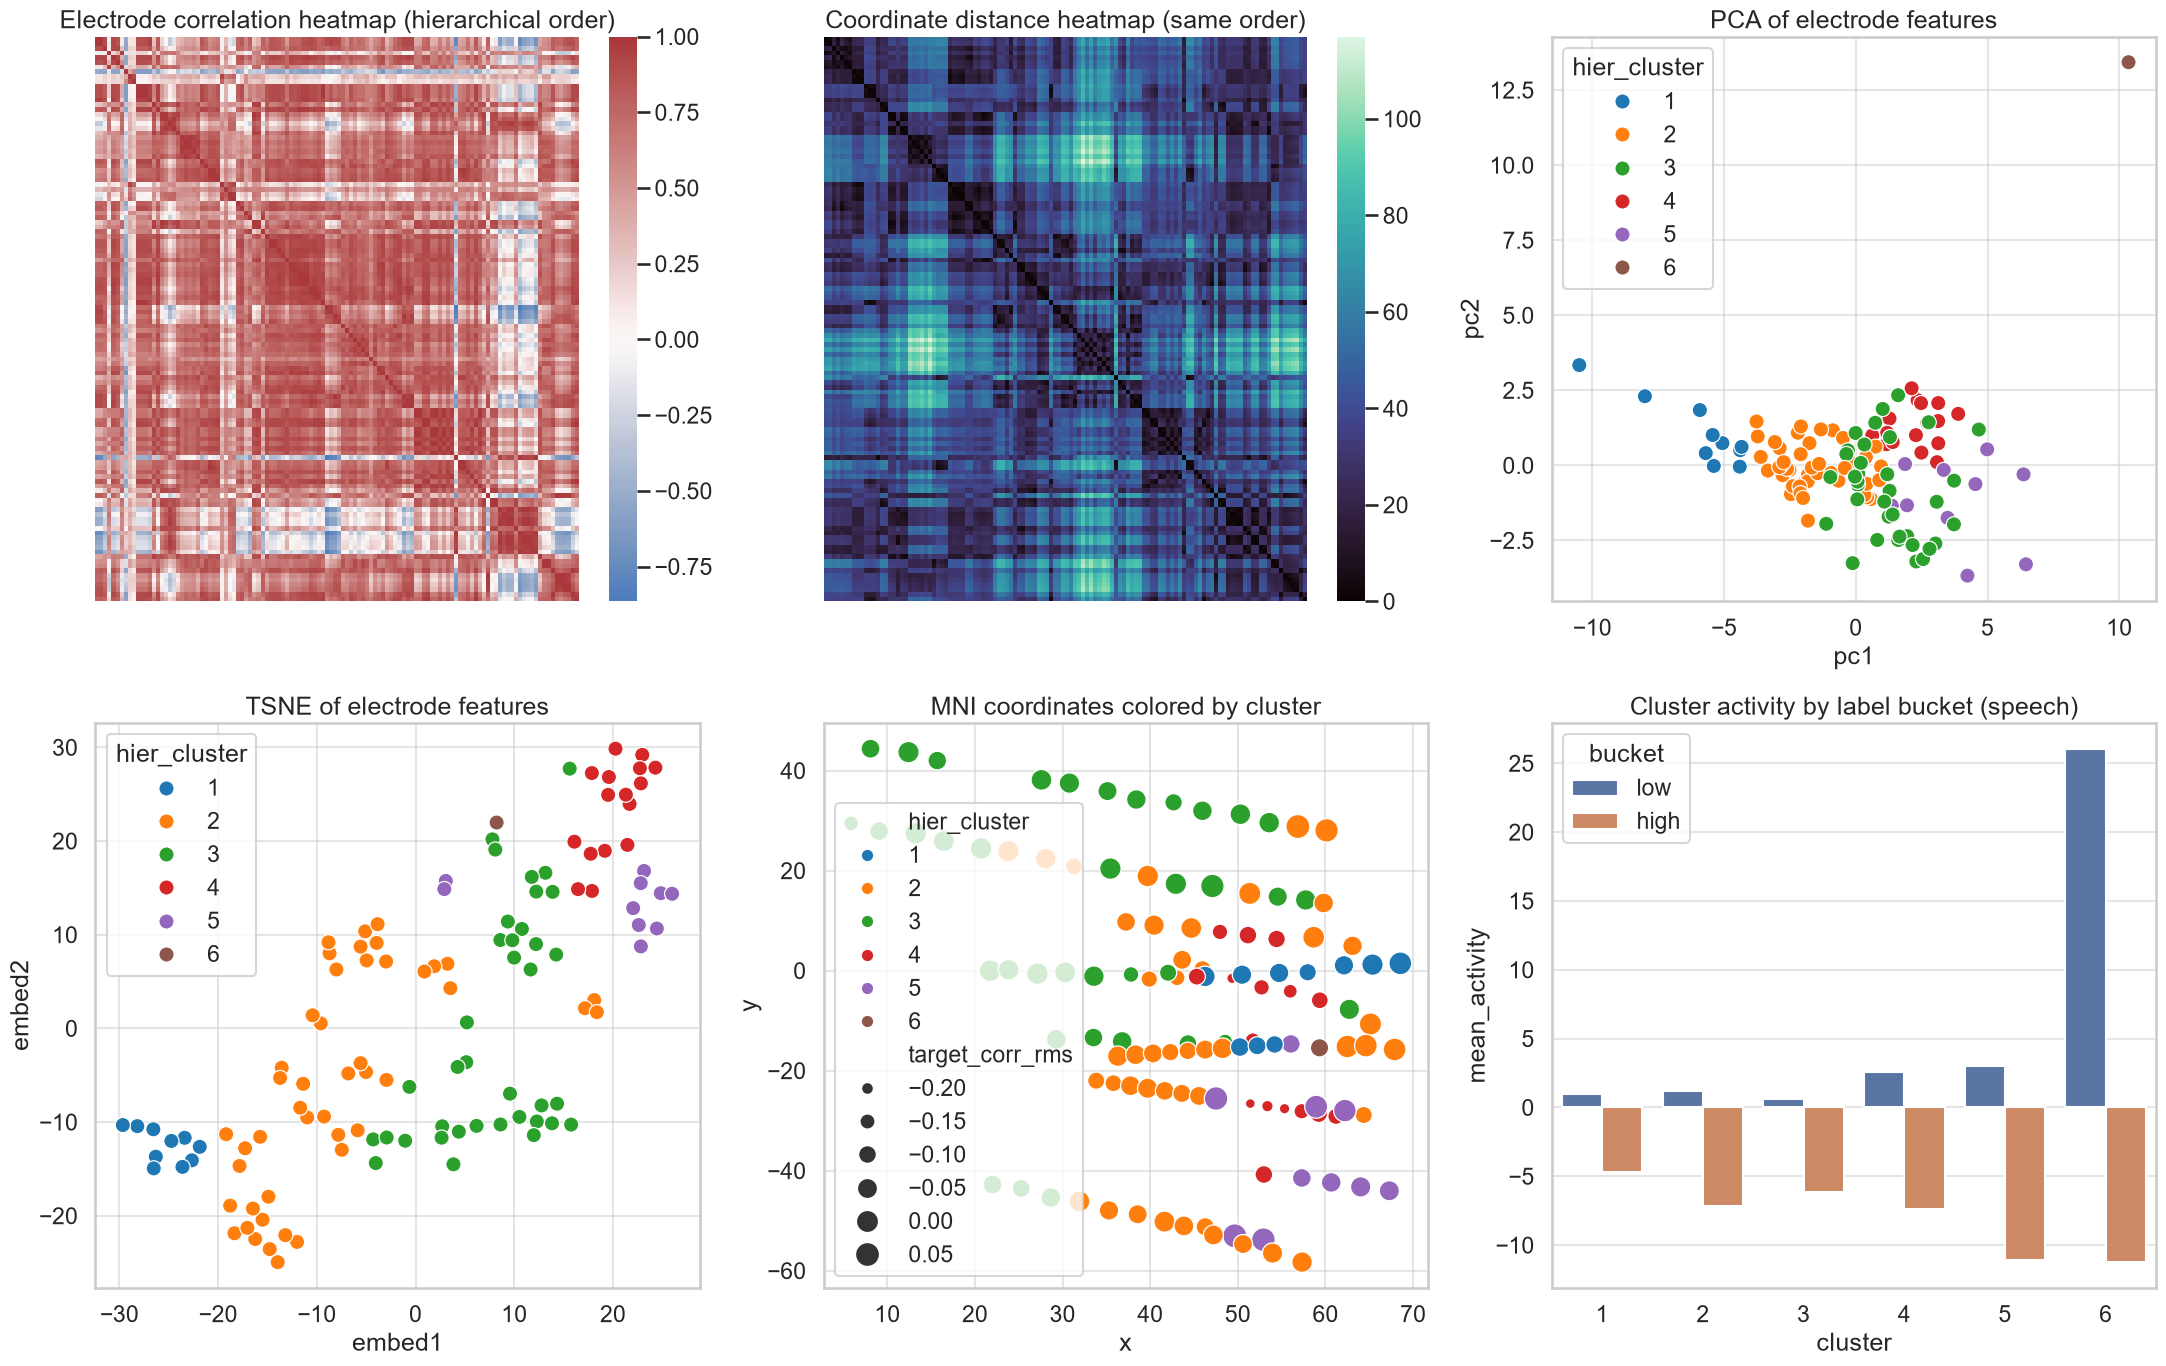

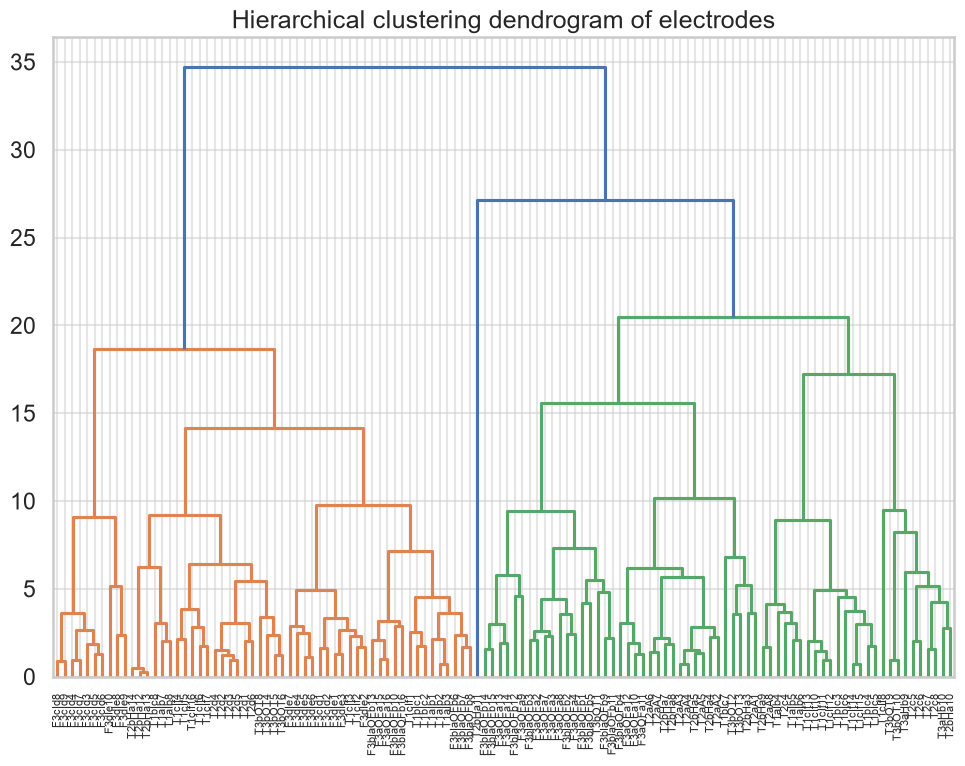

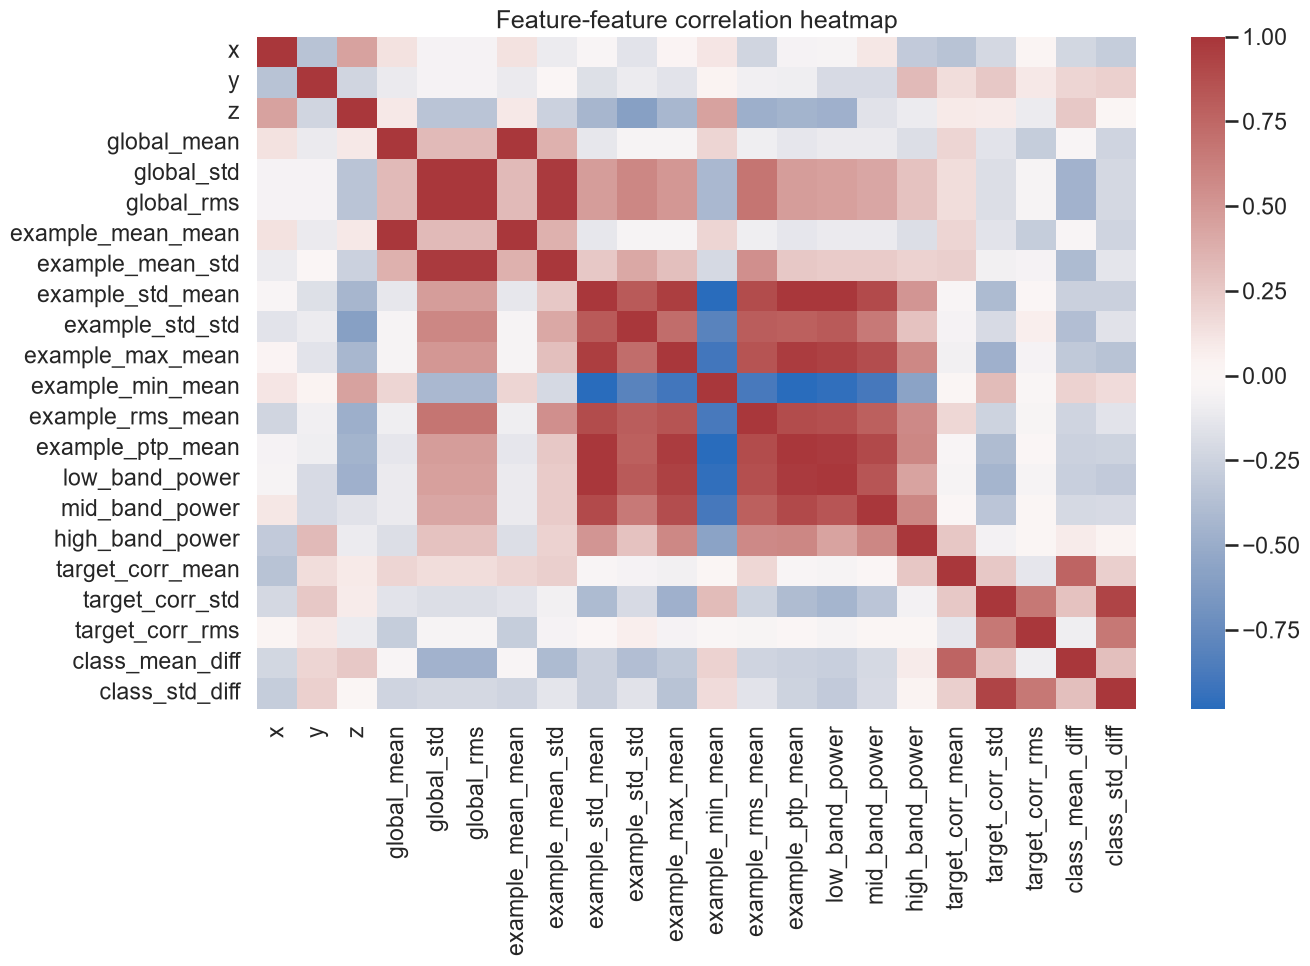

Artifacts ready:
electrode_feature_df <class 'pandas.DataFrame'>
cluster_summary <class 'pandas.DataFrame'>
top_corr_df <class 'pandas.DataFrame'>
cluster_activity_df <class 'pandas.DataFrame'>
hier_labels (120,)
kmeans_labels (120,)
X_train_cluster_avg (1750, 6, 2048)
X_test_cluster_avg (875, 6, 2048)
train_cluster_resid (1750, 6)
test_cluster_resid (875, 6)


In [7]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

try:
    import umap

    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

import neuroprobe.train_test_splits as neuroprobe_train_test_splits

sns.set_theme(style="whitegrid", context="talk")

ANALYSIS_TASK = "speech"  # try "speech" first, then "delta_volume"
ANALYSIS_FOLD = 0
N_CLUSTERS = 6
RANDOM_STATE = 42

folds = neuroprobe_train_test_splits.generate_splits_within_session(
    subject,
    trial_id,
    ANALYSIS_TASK,
    dtype=torch.float32,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True,
)

fold = folds[ANALYSIS_FOLD]
train_dataset = fold["train_dataset"]
test_dataset = fold["test_dataset"]

print("Task:", ANALYSIS_TASK)
print("Fold:", ANALYSIS_FOLD)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


def unpack_item(item):
    if isinstance(item, dict):
        x = item["data"]
        y = item["label"]
    else:
        x, y = item[0], item[1]
    x = x.numpy() if torch.is_tensor(x) else np.asarray(x)
    y = float(y)
    return x.astype(np.float32), y


def dataset_to_tensor(ds):
    X_list, y_list = [], []
    for item in ds:
        x, y = unpack_item(item)
        X_list.append(x)
        y_list.append(y)
    X = np.stack(X_list)  # (n_examples, n_electrodes, time)
    y = np.array(y_list, dtype=np.float32)
    return X, y


X_train_raw, y_train = dataset_to_tensor(train_dataset)
X_test_raw, y_test = dataset_to_tensor(test_dataset)

print("X_train_raw:", X_train_raw.shape)
print("y_train:", y_train.shape)

coords = np.asarray(data_electrode_coordinates, dtype=np.float32)
labels = list(data_electrode_labels)
n_examples, n_electrodes, time_len = X_train_raw.shape

print("coords:", coords.shape)
print("n_electrodes:", n_electrodes)


def safe_corr(a, b, method="pearson"):
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 0.0
    if method == "pearson":
        return pearsonr(a, b)[0]
    return spearmanr(a, b)[0]


def compute_electrode_features(X, y):
    """
    X: (n_examples, n_electrodes, time)
    Returns per-electrode feature dataframe and feature matrix.
    """
    feature_rows = []

    y_binary = None
    if len(np.unique(y)) <= 2:
        y_binary = y.copy()

    for e in range(X.shape[1]):
        xe = X[:, e, :]  # (n_examples, time)

        mean_amp_per_example = xe.mean(axis=1)
        std_amp_per_example = xe.std(axis=1)
        max_amp_per_example = xe.max(axis=1)
        min_amp_per_example = xe.min(axis=1)
        rms_per_example = np.sqrt((xe ** 2).mean(axis=1))
        ptp_per_example = np.ptp(xe, axis=1)

        flat = xe.reshape(-1)
        fft_mag = np.abs(np.fft.rfft(xe, axis=1))
        fft_freq_mean = fft_mag.mean(axis=0)

        low_band = fft_mag[:, 1:8].mean() if fft_mag.shape[1] > 8 else fft_mag.mean()
        mid_band = fft_mag[:, 8:30].mean() if fft_mag.shape[1] > 30 else fft_mag.mean()
        high_band = fft_mag[:, 30:80].mean() if fft_mag.shape[1] > 80 else fft_mag.mean()

        target_corr_mean = safe_corr(mean_amp_per_example, y, method="pearson")
        target_corr_std = safe_corr(std_amp_per_example, y, method="pearson")
        target_corr_rms = safe_corr(rms_per_example, y, method="pearson")

        if y_binary is not None:
            mask0 = y_binary == 0
            mask1 = y_binary == 1
            class_mean_diff = mean_amp_per_example[mask1].mean() - mean_amp_per_example[mask0].mean()
            class_std_diff = std_amp_per_example[mask1].mean() - std_amp_per_example[mask0].mean()
        else:
            class_mean_diff = np.nan
            class_std_diff = np.nan

        feature_rows.append({
            "electrode_idx": e,
            "electrode_label": labels[e],
            "x": coords[e, 0],
            "y": coords[e, 1],
            "z": coords[e, 2],
            "global_mean": float(flat.mean()),
            "global_std": float(flat.std()),
            "global_rms": float(np.sqrt((flat ** 2).mean())),
            "example_mean_mean": float(mean_amp_per_example.mean()),
            "example_mean_std": float(mean_amp_per_example.std()),
            "example_std_mean": float(std_amp_per_example.mean()),
            "example_std_std": float(std_amp_per_example.std()),
            "example_max_mean": float(max_amp_per_example.mean()),
            "example_min_mean": float(min_amp_per_example.mean()),
            "example_rms_mean": float(rms_per_example.mean()),
            "example_ptp_mean": float(ptp_per_example.mean()),
            "low_band_power": float(low_band),
            "mid_band_power": float(mid_band),
            "high_band_power": float(high_band),
            "target_corr_mean": float(target_corr_mean),
            "target_corr_std": float(target_corr_std),
            "target_corr_rms": float(target_corr_rms),
            "class_mean_diff": float(class_mean_diff),
            "class_std_diff": float(class_std_diff),
        })

    feature_df = pd.DataFrame(feature_rows)

    feature_cols = [
        "x", "y", "z",
        "global_mean", "global_std", "global_rms",
        "example_mean_mean", "example_mean_std",
        "example_std_mean", "example_std_std",
        "example_max_mean", "example_min_mean",
        "example_rms_mean", "example_ptp_mean",
        "low_band_power", "mid_band_power", "high_band_power",
        "target_corr_mean", "target_corr_std", "target_corr_rms",
    ]

    if len(np.unique(y)) <= 2:
        feature_cols += ["class_mean_diff", "class_std_diff"]

    feature_matrix = feature_df[feature_cols].to_numpy(dtype=np.float32)
    return feature_df, feature_matrix, feature_cols


electrode_feature_df, electrode_feature_matrix, feature_cols = compute_electrode_features(X_train_raw, y_train)
print(electrode_feature_df.head())
print("feature matrix:", electrode_feature_matrix.shape)

scaler = StandardScaler()
electrode_feature_matrix_z = scaler.fit_transform(electrode_feature_matrix)

# Correlation matrix across electrodes using average time series over examples
avg_signal_per_electrode = X_train_raw.mean(axis=0)  # (n_electrodes, time)
electrode_corr = np.corrcoef(avg_signal_per_electrode)

coord_dist = squareform(pdist(coords, metric="euclidean"))

# Hierarchical clustering
Z = linkage(electrode_feature_matrix_z, method="ward", metric="euclidean")
hier_labels = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")

# KMeans clustering
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans.fit_predict(electrode_feature_matrix_z)

sil_score = silhouette_score(electrode_feature_matrix_z, kmeans_labels)
print("KMeans silhouette score:", sil_score)

electrode_feature_df["hier_cluster"] = hier_labels
electrode_feature_df["kmeans_cluster"] = kmeans_labels

# PCA
pca = PCA(n_components=min(5, electrode_feature_matrix_z.shape[1]))
pca_proj = pca.fit_transform(electrode_feature_matrix_z)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

electrode_feature_df["pc1"] = pca_proj[:, 0]
electrode_feature_df["pc2"] = pca_proj[:, 1]

# UMAP or fallback t-SNE
if HAS_UMAP:
    reducer = umap.UMAP(
        n_neighbors=min(10, n_electrodes - 1),
        min_dist=0.15,
        random_state=RANDOM_STATE,
        metric="euclidean",
    )
    emb2 = reducer.fit_transform(electrode_feature_matrix_z)
    embed_name = "UMAP"
else:
    reducer = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=min(10, n_electrodes - 1))
    emb2 = reducer.fit_transform(electrode_feature_matrix_z)
    embed_name = "TSNE"

electrode_feature_df["embed1"] = emb2[:, 0]
electrode_feature_df["embed2"] = emb2[:, 1]

# Reorder correlation matrix by hierarchical clustering leaf order
dendro = dendrogram(Z, no_plot=True)
order = dendro["leaves"]

corr_reordered = electrode_corr[np.ix_(order, order)]
labels_reordered = [labels[i] for i in order]

# Cluster-level summaries
cluster_summary = (
    electrode_feature_df.groupby("hier_cluster")
    .agg(
        n_electrodes=("electrode_idx", "count"),
        mean_target_corr_mean=("target_corr_mean", "mean"),
        mean_target_corr_std=("target_corr_std", "mean"),
        mean_target_corr_rms=("target_corr_rms", "mean"),
        mean_low_band=("low_band_power", "mean"),
        mean_mid_band=("mid_band_power", "mean"),
        mean_high_band=("high_band_power", "mean"),
        mean_x=("x", "mean"),
        mean_y=("y", "mean"),
        mean_z=("z", "mean"),
    )
    .reset_index()
)

print(cluster_summary.sort_values("mean_target_corr_rms", ascending=False))


# Build cluster transform: average electrodes within each cluster
def cluster_average_transform(X, cluster_labels):
    unique_clusters = np.sort(np.unique(cluster_labels))
    out = []
    for c in unique_clusters:
        idx = np.where(cluster_labels == c)[0]
        out.append(X[:, idx, :].mean(axis=1))
    return np.stack(out, axis=1)  # (n_examples, n_clusters, time)


X_train_cluster_avg = cluster_average_transform(X_train_raw, hier_labels)
X_test_cluster_avg = cluster_average_transform(X_test_raw, hier_labels)

print("X_train_cluster_avg:", X_train_cluster_avg.shape)
print("X_test_cluster_avg:", X_test_cluster_avg.shape)


# Optional: cluster residual transform = raw - cluster mean
def cluster_residual_energy(X, cluster_labels):
    unique_clusters = np.sort(np.unique(cluster_labels))
    rows = []
    for c in unique_clusters:
        idx = np.where(cluster_labels == c)[0]
        cluster_mean = X[:, idx, :].mean(axis=1, keepdims=True)
        residual = X[:, idx, :] - cluster_mean
        rows.append((residual ** 2).mean(axis=(1, 2)))
    return np.stack(rows, axis=1)  # (n_examples, n_clusters)


train_cluster_resid = cluster_residual_energy(X_train_raw, hier_labels)
test_cluster_resid = cluster_residual_energy(X_test_raw, hier_labels)

print("train_cluster_resid:", train_cluster_resid.shape)

# Label-bucketed activity by cluster
if len(np.unique(y_train)) > 2:
    y_bucket = pd.qcut(y_train, q=2, labels=["low", "high"])
else:
    y_bucket = np.where(y_train > 0.5, "high", "low")

cluster_activity_rows = []
for c in np.sort(np.unique(hier_labels)):
    idx = np.where(hier_labels == c)[0]
    cluster_signal = X_train_raw[:, idx, :].mean(axis=(1, 2))
    for bucket_name in ["low", "high"]:
        mask = y_bucket == bucket_name
        cluster_activity_rows.append({
            "cluster": c,
            "bucket": bucket_name,
            "mean_activity": float(cluster_signal[mask].mean()),
            "std_activity": float(cluster_signal[mask].std()),
            "n": int(mask.sum()),
        })

cluster_activity_df = pd.DataFrame(cluster_activity_rows)
print(cluster_activity_df)

# Top electrodes by relationship to target
top_corr_df = electrode_feature_df.reindex(
    electrode_feature_df["target_corr_rms"].abs().sort_values(ascending=False).index
)[[
    "electrode_idx", "electrode_label", "hier_cluster", "kmeans_cluster",
    "x", "y", "z", "target_corr_mean", "target_corr_std", "target_corr_rms"
]]

print(top_corr_df.head(15))

fig, axes = plt.subplots(2, 3, figsize=(22, 14))

sns.heatmap(
    corr_reordered,
    cmap="vlag",
    center=0,
    ax=axes[0, 0],
    xticklabels=False,
    yticklabels=False,
)
axes[0, 0].set_title("Electrode correlation heatmap (hierarchical order)")

sns.heatmap(
    coord_dist[np.ix_(order, order)],
    cmap="mako",
    ax=axes[0, 1],
    xticklabels=False,
    yticklabels=False,
)
axes[0, 1].set_title("Coordinate distance heatmap (same order)")

sns.scatterplot(
    data=electrode_feature_df,
    x="pc1",
    y="pc2",
    hue="hier_cluster",
    palette="tab10",
    s=120,
    ax=axes[0, 2],
)
axes[0, 2].set_title("PCA of electrode features")

sns.scatterplot(
    data=electrode_feature_df,
    x="embed1",
    y="embed2",
    hue="hier_cluster",
    palette="tab10",
    s=120,
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"{embed_name} of electrode features")

sns.scatterplot(
    data=electrode_feature_df,
    x="x",
    y="y",
    hue="hier_cluster",
    size="target_corr_rms",
    sizes=(50, 300),
    palette="tab10",
    ax=axes[1, 1],
)
axes[1, 1].set_title("MNI coordinates colored by cluster")

sns.barplot(
    data=cluster_activity_df,
    x="cluster",
    y="mean_activity",
    hue="bucket",
    ax=axes[1, 2],
)
axes[1, 2].set_title(f"Cluster activity by label bucket ({ANALYSIS_TASK})")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
dendrogram(Z, labels=np.array(labels), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical clustering dendrogram of electrodes")
plt.tight_layout()
plt.show()

feature_corr = pd.DataFrame(
    electrode_feature_matrix_z,
    index=labels,
    columns=feature_cols
).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(feature_corr, cmap="vlag", center=0)
plt.title("Feature-feature correlation heatmap")
plt.tight_layout()
plt.show()

analysis_artifacts = {
    "electrode_feature_df": electrode_feature_df,
    "cluster_summary": cluster_summary,
    "top_corr_df": top_corr_df,
    "cluster_activity_df": cluster_activity_df,
    "hier_labels": hier_labels,
    "kmeans_labels": kmeans_labels,
    "X_train_cluster_avg": X_train_cluster_avg,
    "X_test_cluster_avg": X_test_cluster_avg,
    "train_cluster_resid": train_cluster_resid,
    "test_cluster_resid": test_cluster_resid,
}

print("Artifacts ready:")
for k, v in analysis_artifacts.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)
    else:
        print(k, type(v))

I think the clustering could be a cool addition that might give better results but I'm skeptical that it will be anything more than a slight boost.

In [8]:

class NeuroprobeMultiViewDataset(Dataset):
    def __init__(self, raw_X, cluster_X, y, subject_id=0):
        assert raw_X.shape[0] == cluster_X.shape[0] == y.shape[0]
        self.raw_X = raw_X
        self.cluster_X = cluster_X
        self.y = y
        self.subject_id = subject_id

    def __len__(self):
        return self.raw_X.shape[0]

    def __getitem__(self, idx):
        x_raw = self.raw_X[idx]  # (n_electrodes, time)
        x_cluster = self.cluster_X[idx]  # (n_clusters, time)
        y = self.y[idx]

        x_raw = torch.tensor(x_raw, dtype=torch.float32)
        x_cluster = torch.tensor(x_cluster, dtype=torch.float32)
        y = torch.tensor(float(y), dtype=torch.float32)
        subject_idx = torch.tensor(self.subject_id, dtype=torch.long)
        return x_raw, x_cluster, y, subject_idx


# Helper to build multi-view datasets per task/fold
def build_multi_view_datasets_for_task(task_name, fold_idx):
    folds = neuroprobe_train_test_splits.generate_splits_within_session(
        subject,
        trial_id,
        task_name,
        dtype=torch.float32,
        output_indices=output_indices,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True,
    )
    fold = folds[fold_idx]
    train_ds = fold["train_dataset"]
    test_ds = fold["test_dataset"]

    X_train_raw_task, y_train_task = dataset_to_tensor(train_ds)
    X_test_raw_task, y_test_task = dataset_to_tensor(test_ds)

    # IMPORTANT: reuse the same cluster_labels (hier_labels) computed
    # on speech, or recompute per-task if you prefer. For now, reuse hier_labels.
    X_train_cluster_task = cluster_average_transform(X_train_raw_task, hier_labels)
    X_test_cluster_task = cluster_average_transform(X_test_raw_task, hier_labels)

    train_mv_ds = NeuroprobeMultiViewDataset(
        raw_X=X_train_raw_task,
        cluster_X=X_train_cluster_task,
        y=y_train_task,
        subject_id=0,
    )
    test_mv_ds = NeuroprobeMultiViewDataset(
        raw_X=X_test_raw_task,
        cluster_X=X_test_cluster_task,
        y=y_test_task,
        subject_id=0,
    )

    return train_mv_ds, test_mv_ds

In [9]:

class SharedRawClusterCNNEncoder(nn.Module):
    def __init__(
            self,
            n_electrodes,
            n_clusters,
            electrode_coordinates,
            num_subjects=1,
            coord_dim=8,
            electrode_emb_dim=8,
            subject_emb_dim=4,
            raw_hidden_channels=16,
            cluster_hidden_channels=8,
            proj_dim=64,
            dropout=0.2,
    ):
        super().__init__()
        self.n_electrodes = n_electrodes
        self.n_clusters = n_clusters

        coord_tensor = torch.as_tensor(
            electrode_coordinates, dtype=torch.float32
        ).clone().detach()
        self.register_buffer("electrode_coordinates", coord_tensor)

        self.coord_mlp = nn.Sequential(
            nn.Linear(3, coord_dim),
            nn.LayerNorm(coord_dim),
            nn.ReLU(),
        )
        self.electrode_embedding = nn.Embedding(n_electrodes, electrode_emb_dim)
        self.subject_embedding = nn.Embedding(num_subjects, subject_emb_dim)

        self.electrode_gate = nn.Sequential(
            nn.Linear(coord_dim + electrode_emb_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

        self.raw_cnn = nn.Sequential(
            nn.Conv1d(n_electrodes, raw_hidden_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(raw_hidden_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(raw_hidden_channels, raw_hidden_channels * 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(raw_hidden_channels * 2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(raw_hidden_channels * 2, raw_hidden_channels * 4, kernel_size=5, padding=2),
            nn.BatchNorm1d(raw_hidden_channels * 4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.cluster_cnn = nn.Sequential(
            nn.Conv1d(n_clusters, cluster_hidden_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(cluster_hidden_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(cluster_hidden_channels, cluster_hidden_channels * 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(cluster_hidden_channels * 2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        raw_out_dim = raw_hidden_channels * 4
        cluster_out_dim = cluster_hidden_channels * 2
        meta_dim = coord_dim + electrode_emb_dim + subject_emb_dim

        self.proj = nn.Sequential(
            nn.Linear(raw_out_dim + cluster_out_dim + meta_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x_raw, x_cluster, subject_idx):
        batch_size, n_electrodes, _ = x_raw.shape
        device = x_raw.device

        coords = self.electrode_coordinates.to(device)
        coord_features = self.coord_mlp(coords)

        electrode_ids = torch.arange(n_electrodes, device=device)
        electrode_features = self.electrode_embedding(electrode_ids)

        gate_in = torch.cat([coord_features, electrode_features], dim=-1)
        gates = self.electrode_gate(gate_in).squeeze(-1).view(1, n_electrodes, 1)
        x_raw = x_raw * gates

        raw_feat = self.raw_cnn(x_raw).squeeze(-1)
        cluster_feat = self.cluster_cnn(x_cluster).squeeze(-1)

        pooled_coord = coord_features.mean(dim=0, keepdim=True).expand(batch_size, -1)
        pooled_elec = electrode_features.mean(dim=0, keepdim=True).expand(batch_size, -1)
        subj_feat = self.subject_embedding(subject_idx)

        combined = torch.cat([raw_feat, cluster_feat, pooled_coord, pooled_elec, subj_feat], dim=-1)
        z = self.proj(combined)
        return z


class MultiTaskRawClusterBrainCNN(nn.Module):
    def __init__(self, n_electrodes, n_clusters, electrode_coordinates, num_subjects=1, dropout=0.2):
        super().__init__()
        self.encoder = SharedRawClusterCNNEncoder(
            n_electrodes=n_electrodes,
            n_clusters=n_clusters,
            electrode_coordinates=electrode_coordinates,
            num_subjects=num_subjects,
            coord_dim=8,
            electrode_emb_dim=8,
            subject_emb_dim=4,
            raw_hidden_channels=16,
            cluster_hidden_channels=8,
            proj_dim=64,
            dropout=dropout,
        )

        self.heads = nn.ModuleDict({
            "delta_volume": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
            "speech": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
            "pitch": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
            "gpt2_surprisal": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
            "word_gap": nn.Sequential(
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
            ),
        })

    def forward(self, x_raw, x_cluster, subject_idx, task_name):
        z = self.encoder(x_raw, x_cluster, subject_idx)
        out = self.heads[task_name](z).squeeze(-1)
        return out

In [10]:

task_train_loaders = {}
task_test_loaders = {}

for task_name in TASKS:
    train_mv_ds, test_mv_ds = build_multi_view_datasets_for_task(task_name, fold_idx=0)
    task_train_loaders[task_name] = DataLoader(
        train_mv_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    task_test_loaders[task_name] = DataLoader(
        test_mv_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

sample_x_raw, sample_x_cluster, _, _ = next(iter(task_train_loaders["speech"]))
n_electrodes = sample_x_raw.shape[1]
n_clusters = sample_x_cluster.shape[1]

model = MultiTaskRawClusterBrainCNN(
    n_electrodes=n_electrodes,
    n_clusters=n_clusters,
    electrode_coordinates=data_electrode_coordinates,
    num_subjects=1,
    dropout=0.25,
).to(device)

criteria = {
    "delta_volume": nn.MSELoss(),
    "speech": nn.BCEWithLogitsLoss(),
    "pitch": nn.MSELoss(),
    "gpt2_surprisal": nn.MSELoss(),
    "word_gap": nn.MSELoss(),
}

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BASE_LR,
    weight_decay=WEIGHT_DECAY,
)

task_lr_mult = {task: 1.0 for task in TASKS}
task_loss_history = {task: [] for task in TASKS}
best_score = -np.inf
best_state_dict = None
epochs_without_improvement = 0
history_rows = []


def train_one_task_epoch_mv(model, loader, optimizer, criterion, device, task_name):
    model.train()
    total_loss = 0.0
    n_examples = 0

    for x_raw, x_cluster, y, subject_idx in loader:
        x_raw = x_raw.to(device, non_blocking=True)
        x_cluster = x_cluster.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        subject_idx = subject_idx.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(x_raw, x_cluster, subject_idx, task_name)
        loss = criterion(preds, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * x_raw.size(0)
        n_examples += x_raw.size(0)

    return total_loss / max(n_examples, 1)


@torch.no_grad()
def evaluate_task_mv(model, loader, criterion, device, task_name):
    model.eval()
    total_loss = 0.0
    all_y, all_preds = [], []

    for x_raw, x_cluster, y, subject_idx in loader:
        x_raw = x_raw.to(device, non_blocking=True)
        x_cluster = x_cluster.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        subject_idx = subject_idx.to(device, non_blocking=True)

        preds = model(x_raw, x_cluster, subject_idx, task_name)
        loss = criterion(preds, y)

        total_loss += loss.item() * x_raw.size(0)
        all_y.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)

    if task_name in CLASSIFICATION_TASKS:
        if len(np.unique(y_true)) < 2:
            metric = np.nan
        else:
            metric = roc_auc_score(y_true, y_pred)
        metric_name = "auroc"
        baseline_metric = 0.5
    else:
        metric = r2_score(y_true, y_pred)
        baseline_pred = np.full_like(y_true, fill_value=y_true.mean())
        baseline_metric = r2_score(y_true, baseline_pred)
        metric_name = "r2"

    return {
        "loss": total_loss / len(loader.dataset),
        "metric_name": metric_name,
        "metric": metric,
        "baseline_metric": baseline_metric,
    }


for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n========== MV Epoch {epoch:02d} ==========")

    epoch_train_losses = {}
    epoch_eval = {}

    for task_name in TASKS:
        current_lr = BASE_LR * task_lr_mult[task_name]
        set_optimizer_lr(optimizer, current_lr)

        train_loss = train_one_task_epoch_mv(
            model=model,
            loader=task_train_loaders[task_name],
            optimizer=optimizer,
            criterion=criteria[task_name],
            device=device,
            task_name=task_name,
        )
        epoch_train_losses[task_name] = train_loss
        task_loss_history[task_name].append(train_loss)

        eval_out = evaluate_task_mv(
            model=model,
            loader=task_test_loaders[task_name],
            criterion=criteria[task_name],
            device=device,
            task_name=task_name,
        )
        epoch_eval[task_name] = eval_out

        print(
            f"{task_name:15s} | "
            f"lr_mult={task_lr_mult[task_name]:.3f} | "
            f"train_loss={train_loss:.4f} | "
            f"test_loss={eval_out['loss']:.4f} | "
            f"{eval_out['metric_name']}={eval_out['metric']:.4f} | "
            f"baseline={eval_out['baseline_metric']:.4f}"
        )

    # adaptive LR update
    for task_name in TASKS:
        losses = task_loss_history[task_name]
        if len(losses) >= 2:
            delta = losses[-1] - losses[-2]
            if delta > LOSS_DELTA_EPS:
                task_lr_mult[task_name] *= LR_DOWN
            elif delta < -LOSS_DELTA_EPS:
                task_lr_mult[task_name] *= LR_UP
            task_lr_mult[task_name] = float(
                np.clip(task_lr_mult[task_name], MIN_LR_MULT, MAX_LR_MULT)
            )

    normalized_scores = []
    for task_name in TASKS:
        metric = epoch_eval[task_name]["metric"]
        baseline = epoch_eval[task_name]["baseline_metric"]

        if np.isnan(metric):
            continue
        norm_score = metric - baseline
        normalized_scores.append(norm_score)

    combined_score = float(np.mean(normalized_scores)) if normalized_scores else -np.inf
    print(f"Combined MV score: {combined_score:.4f}")

    for task_name in TASKS:
        history_rows.append({
            "epoch": epoch,
            "task": task_name,
            "lr_mult": task_lr_mult[task_name],
            "train_loss": epoch_train_losses[task_name],
            "test_loss": epoch_eval[task_name]["loss"],
            "metric_name": epoch_eval[task_name]["metric_name"],
            "metric": epoch_eval[task_name]["metric"],
            "baseline_metric": epoch_eval[task_name]["baseline_metric"],
            "combined_score": combined_score,
        })

    if combined_score > best_score:
        best_score = combined_score
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Best combined MV score so far: {best_score:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at MV epoch {epoch}")
        break


========== MV Epoch 01 ==========
delta_volume    | lr_mult=1.000 | train_loss=0.2915 | test_loss=0.2164 | r2=0.1344 | baseline=0.0000
speech          | lr_mult=1.000 | train_loss=0.6712 | test_loss=0.6897 | auroc=0.5721 | baseline=0.5000
pitch           | lr_mult=1.000 | train_loss=0.3226 | test_loss=0.2684 | r2=-0.0736 | baseline=0.0000
gpt2_surprisal  | lr_mult=1.000 | train_loss=0.3567 | test_loss=0.2628 | r2=-0.0511 | baseline=0.0000
word_gap        | lr_mult=1.000 | train_loss=0.4117 | test_loss=0.2509 | r2=-0.0037 | baseline=0.0000
Combined MV score: 0.0156
Best combined MV score so far: 0.0156

========== MV Epoch 02 ==========
delta_volume    | lr_mult=1.000 | train_loss=0.2536 | test_loss=0.1998 | r2=0.2008 | baseline=0.0000
speech          | lr_mult=1.000 | train_loss=0.6392 | test_loss=0.6593 | auroc=0.6634 | baseline=0.5000
pitch           | lr_mult=1.000 | train_loss=0.2651 | test_loss=0.2639 | r2=-0.0555 | baseline=0.0000
gpt2_surprisal  | lr_mult=1.000 | train_loss=0.2

In [11]:
import copy
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import neuroprobe.train_test_splits as neuroprobe_train_test_splits

# =========================
# Config
# =========================
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TASKS = ["delta_volume", "speech", "pitch", "gpt2_surprisal", "word_gap"]
CLASSIFICATION_TASKS = {"speech"}
REGRESSION_TASKS = set(TASKS) - CLASSIFICATION_TASKS

FOLD_IDX = 0
BATCH_SIZE = 32
BASE_LR = 3e-4
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 12
PATIENCE = 4
NUM_WORKERS = 0
N_CLUSTERS = 6

print("DEVICE:", DEVICE)

# =========================
# Repro
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# =========================
# Utilities
# =========================
def unpack_item(item):
    if isinstance(item, dict):
        x = item["data"]
        y = item["label"]
    else:
        x, y = item[0], item[1]

    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    else:
        x = np.asarray(x)

    if torch.is_tensor(y):
        y = y.detach().cpu().item()
    else:
        y = float(y)

    return x.astype(np.float32), float(y)

def dataset_to_tensor(ds):
    X_list, y_list = [], []
    for item in ds:
        x, y = unpack_item(item)
        X_list.append(x)
        y_list.append(y)
    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.float32)
    return X, y

def build_fold_raw(task_name, fold_idx=0):
    folds = neuroprobe_train_test_splits.generate_splits_within_session(
        subject,
        trial_id,
        task_name,
        dtype=torch.float32,
        output_indices=output_indices,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True,
    )
    fold = folds[fold_idx]
    X_train, y_train = dataset_to_tensor(fold["train_dataset"])
    X_test, y_test = dataset_to_tensor(fold["test_dataset"])
    return X_train, y_train, X_test, y_test

def compute_simple_electrode_features(X, y):
    n_examples, n_electrodes, time_len = X.shape
    rows = []
    for e in range(n_electrodes):
        xe = X[:, e, :]
        mean_amp = xe.mean(axis=1)
        std_amp = xe.std(axis=1)
        rms_amp = np.sqrt((xe ** 2).mean(axis=1))

        if np.std(mean_amp) < 1e-8:
            corr_mean = 0.0
        else:
            corr_mean = np.corrcoef(mean_amp, y)[0, 1]
            if np.isnan(corr_mean):
                corr_mean = 0.0

        if np.std(std_amp) < 1e-8:
            corr_std = 0.0
        else:
            corr_std = np.corrcoef(std_amp, y)[0, 1]
            if np.isnan(corr_std):
                corr_std = 0.0

        if np.std(rms_amp) < 1e-8:
            corr_rms = 0.0
        else:
            corr_rms = np.corrcoef(rms_amp, y)[0, 1]
            if np.isnan(corr_rms):
                corr_rms = 0.0

        rows.append([
            data_electrode_coordinates[e, 0],
            data_electrode_coordinates[e, 1],
            data_electrode_coordinates[e, 2],
            float(xe.mean()),
            float(xe.std()),
            float(np.sqrt((xe ** 2).mean())),
            float(mean_amp.mean()),
            float(mean_amp.std()),
            float(std_amp.mean()),
            float(std_amp.std()),
            float(rms_amp.mean()),
            float(corr_mean),
            float(corr_std),
            float(corr_rms),
        ])
    return np.array(rows, dtype=np.float32)

def fit_clusters_from_reference_task(task_name="speech", fold_idx=0, n_clusters=6):
    X_train, y_train, _, _ = build_fold_raw(task_name, fold_idx=fold_idx)
    feat = compute_simple_electrode_features(X_train, y_train)
    scaler = StandardScaler()
    feat_z = scaler.fit_transform(feat)
    km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20)
    cluster_labels = km.fit_predict(feat_z)
    return cluster_labels

def cluster_average_transform(X, cluster_labels):
    unique_clusters = np.sort(np.unique(cluster_labels))
    out = []
    for c in unique_clusters:
        idx = np.where(cluster_labels == c)[0]
        out.append(X[:, idx, :].mean(axis=1))
    return np.stack(out, axis=1).astype(np.float32)

# =========================
# Dataset classes
# =========================
class RawOnlyDataset(Dataset):
    def __init__(self, raw_X, y, subject_id=0):
        self.raw_X = raw_X
        self.y = y
        self.subject_id = subject_id

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_raw = torch.tensor(self.raw_X[idx], dtype=torch.float32)
        y = torch.tensor(float(self.y[idx]), dtype=torch.float32)
        subject_idx = torch.tensor(self.subject_id, dtype=torch.long)
        return x_raw, y, subject_idx

class MultiViewDataset(Dataset):
    def __init__(self, raw_X, cluster_X, y, subject_id=0):
        self.raw_X = raw_X
        self.cluster_X = cluster_X
        self.y = y
        self.subject_id = subject_id

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_raw = torch.tensor(self.raw_X[idx], dtype=torch.float32)
        x_cluster = torch.tensor(self.cluster_X[idx], dtype=torch.float32)
        y = torch.tensor(float(self.y[idx]), dtype=torch.float32)
        subject_idx = torch.tensor(self.subject_id, dtype=torch.long)
        return x_raw, x_cluster, y, subject_idx

# =========================
# Models
# =========================
class RawOnlySharedCNN(nn.Module):
    def __init__(self, n_electrodes, electrode_coordinates, num_subjects=1, dropout=0.25):
        super().__init__()
        coord_tensor = torch.as_tensor(electrode_coordinates, dtype=torch.float32).clone().detach()
        self.register_buffer("electrode_coordinates", coord_tensor)

        self.coord_mlp = nn.Sequential(
            nn.Linear(3, 8),
            nn.LayerNorm(8),
            nn.ReLU(),
        )

        self.electrode_embedding = nn.Embedding(n_electrodes, 8)
        self.subject_embedding = nn.Embedding(num_subjects, 4)

        self.electrode_gate = nn.Sequential(
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

        self.raw_cnn = nn.Sequential(
            nn.Conv1d(n_electrodes, 16, kernel_size=9, padding=4),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.proj = nn.Sequential(
            nn.Linear(64 + 8 + 8 + 4, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def encode(self, x_raw, subject_idx):
        batch_size, n_electrodes, _ = x_raw.shape
        device = x_raw.device

        coords = self.electrode_coordinates.to(device)
        coord_feat = self.coord_mlp(coords)
        elec_ids = torch.arange(n_electrodes, device=device)
        elec_feat = self.electrode_embedding(elec_ids)

        gate_in = torch.cat([coord_feat, elec_feat], dim=-1)
        gates = self.electrode_gate(gate_in).squeeze(-1).view(1, n_electrodes, 1)
        x_raw = x_raw * gates

        raw_feat = self.raw_cnn(x_raw).squeeze(-1)
        pooled_coord = coord_feat.mean(dim=0, keepdim=True).expand(batch_size, -1)
        pooled_elec = elec_feat.mean(dim=0, keepdim=True).expand(batch_size, -1)
        subj_feat = self.subject_embedding(subject_idx)

        z = torch.cat([raw_feat, pooled_coord, pooled_elec, subj_feat], dim=-1)
        z = self.proj(z)
        return z

class MultiTaskRawOnlyBrainCNN(nn.Module):
    def __init__(self, n_electrodes, electrode_coordinates, num_subjects=1, dropout=0.25):
        super().__init__()
        self.encoder = RawOnlySharedCNN(
            n_electrodes=n_electrodes,
            electrode_coordinates=electrode_coordinates,
            num_subjects=num_subjects,
            dropout=dropout,
        )
        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            ) for task in TASKS
        })

    def forward(self, x_raw, subject_idx, task_name):
        z = self.encoder.encode(x_raw, subject_idx)
        return self.heads[task_name](z).squeeze(-1)

class RawClusterSharedCNN(nn.Module):
    def __init__(self, n_electrodes, n_clusters, electrode_coordinates, num_subjects=1, dropout=0.25):
        super().__init__()
        coord_tensor = torch.as_tensor(electrode_coordinates, dtype=torch.float32).clone().detach()
        self.register_buffer("electrode_coordinates", coord_tensor)

        self.coord_mlp = nn.Sequential(
            nn.Linear(3, 8),
            nn.LayerNorm(8),
            nn.ReLU(),
        )

        self.electrode_embedding = nn.Embedding(n_electrodes, 8)
        self.subject_embedding = nn.Embedding(num_subjects, 4)

        self.electrode_gate = nn.Sequential(
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

        self.raw_cnn = nn.Sequential(
            nn.Conv1d(n_electrodes, 16, kernel_size=9, padding=4),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.cluster_cnn = nn.Sequential(
            nn.Conv1d(n_clusters, 8, kernel_size=9, padding=4),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(8, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.proj = nn.Sequential(
            nn.Linear(64 + 16 + 8 + 8 + 4, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def encode(self, x_raw, x_cluster, subject_idx):
        batch_size, n_electrodes, _ = x_raw.shape
        device = x_raw.device

        coords = self.electrode_coordinates.to(device)
        coord_feat = self.coord_mlp(coords)
        elec_ids = torch.arange(n_electrodes, device=device)
        elec_feat = self.electrode_embedding(elec_ids)

        gate_in = torch.cat([coord_feat, elec_feat], dim=-1)
        gates = self.electrode_gate(gate_in).squeeze(-1).view(1, n_electrodes, 1)
        x_raw = x_raw * gates

        raw_feat = self.raw_cnn(x_raw).squeeze(-1)
        cluster_feat = self.cluster_cnn(x_cluster).squeeze(-1)

        pooled_coord = coord_feat.mean(dim=0, keepdim=True).expand(batch_size, -1)
        pooled_elec = elec_feat.mean(dim=0, keepdim=True).expand(batch_size, -1)
        subj_feat = self.subject_embedding(subject_idx)

        z = torch.cat([raw_feat, cluster_feat, pooled_coord, pooled_elec, subj_feat], dim=-1)
        z = self.proj(z)
        return z

class MultiTaskRawClusterBrainCNN(nn.Module):
    def __init__(self, n_electrodes, n_clusters, electrode_coordinates, num_subjects=1, dropout=0.25):
        super().__init__()
        self.encoder = RawClusterSharedCNN(
            n_electrodes=n_electrodes,
            n_clusters=n_clusters,
            electrode_coordinates=electrode_coordinates,
            num_subjects=num_subjects,
            dropout=dropout,
        )
        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            ) for task in TASKS
        })

    def forward(self, x_raw, x_cluster, subject_idx, task_name):
        z = self.encoder.encode(x_raw, x_cluster, subject_idx)
        return self.heads[task_name](z).squeeze(-1)

# =========================
# Loss wrapper
# =========================
class MultiTaskLossWrapper(nn.Module):
    def __init__(self, task_names):
        super().__init__()
        self.task_names = list(task_names)
        self.log_vars = nn.ParameterDict({
            task: nn.Parameter(torch.zeros(1)) for task in self.task_names
        })

    def forward(self, task_losses):
        total_loss = 0.0
        for task_name, loss in task_losses.items():
            log_var = self.log_vars[task_name]
            precision = torch.exp(-log_var)
            total_loss = total_loss + precision * loss + log_var
        return total_loss

    @torch.no_grad()
    def current_weights(self):
        return {
            task: float(torch.exp(-self.log_vars[task]).detach().cpu().item())
            for task in self.task_names
        }

# =========================
# Metrics
# =========================
@torch.no_grad()
def evaluate_rawonly(model, loader, criterion, device, task_name):
    model.eval()
    total_loss = 0.0
    all_y, all_preds = [], []

    for x_raw, y, subject_idx in loader:
        x_raw = x_raw.to(device)
        y = y.to(device)
        subject_idx = subject_idx.to(device)

        preds = model(x_raw, subject_idx, task_name)
        loss = criterion(preds, y)

        total_loss += loss.item() * x_raw.size(0)
        all_y.append(y.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)

    if task_name in CLASSIFICATION_TASKS:
        metric_name = "auroc"
        baseline = 0.5
        metric = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) >= 2 else np.nan
    else:
        metric_name = "r2"
        baseline_pred = np.full_like(y_true, fill_value=y_true.mean())
        baseline = r2_score(y_true, baseline_pred)
        metric = r2_score(y_true, y_pred)

    return {"loss": total_loss / len(loader.dataset), "metric_name": metric_name, "metric": metric, "baseline_metric": baseline}

@torch.no_grad()
def evaluate_multiview(model, loader, criterion, device, task_name):
    model.eval()
    total_loss = 0.0
    all_y, all_preds = [], []

    for x_raw, x_cluster, y, subject_idx in loader:
        x_raw = x_raw.to(device)
        x_cluster = x_cluster.to(device)
        y = y.to(device)
        subject_idx = subject_idx.to(device)

        preds = model(x_raw, x_cluster, subject_idx, task_name)
        loss = criterion(preds, y)

        total_loss += loss.item() * x_raw.size(0)
        all_y.append(y.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)

    if task_name in CLASSIFICATION_TASKS:
        metric_name = "auroc"
        baseline = 0.5
        metric = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) >= 2 else np.nan
    else:
        metric_name = "r2"
        baseline_pred = np.full_like(y_true, fill_value=y_true.mean())
        baseline = r2_score(y_true, baseline_pred)
        metric = r2_score(y_true, y_pred)

    return {"loss": total_loss / len(loader.dataset), "metric_name": metric_name, "metric": metric, "baseline_metric": baseline}

def combined_score_from_eval(epoch_eval):
    scores = []
    for task_name, out in epoch_eval.items():
        if np.isnan(out["metric"]):
            continue
        scores.append(out["metric"] - out["baseline_metric"])
    return float(np.mean(scores)) if len(scores) else -np.inf

# =========================
# Data prep
# =========================
print("Fitting clusters from reference task...")
cluster_labels = fit_clusters_from_reference_task(task_name="speech", fold_idx=FOLD_IDX, n_clusters=N_CLUSTERS)
print("Cluster counts:", pd.Series(cluster_labels).value_counts().sort_index().to_dict())

raw_train_loaders = {}
raw_test_loaders = {}
mv_train_loaders = {}
mv_test_loaders = {}

for task_name in TASKS:
    X_train, y_train, X_test, y_test = build_fold_raw(task_name, fold_idx=FOLD_IDX)

    raw_train_ds = RawOnlyDataset(X_train, y_train, subject_id=0)
    raw_test_ds = RawOnlyDataset(X_test, y_test, subject_id=0)

    X_train_cluster = cluster_average_transform(X_train, cluster_labels)
    X_test_cluster = cluster_average_transform(X_test, cluster_labels)

    mv_train_ds = MultiViewDataset(X_train, X_train_cluster, y_train, subject_id=0)
    mv_test_ds = MultiViewDataset(X_test, X_test_cluster, y_test, subject_id=0)

    raw_train_loaders[task_name] = DataLoader(
        raw_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )
    raw_test_loaders[task_name] = DataLoader(
        raw_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )
    mv_train_loaders[task_name] = DataLoader(
        mv_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )
    mv_test_loaders[task_name] = DataLoader(
        mv_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

sample_raw, _, _ = next(iter(raw_train_loaders["speech"]))
sample_mv_raw, sample_mv_cluster, _, _ = next(iter(mv_train_loaders["speech"]))
n_electrodes = sample_raw.shape[1]
n_clusters = sample_mv_cluster.shape[1]
print("n_electrodes:", n_electrodes, "n_clusters:", n_clusters)

criteria = {
    "delta_volume": nn.MSELoss(),
    "speech": nn.BCEWithLogitsLoss(),
    "pitch": nn.MSELoss(),
    "gpt2_surprisal": nn.MSELoss(),
    "word_gap": nn.MSELoss(),
}

# =========================
# Training variants
# =========================
def train_variant_rawonly():
    print("\n================ Variant A: Raw-only sequential ================\n")
    model = MultiTaskRawOnlyBrainCNN(
        n_electrodes=n_electrodes,
        electrode_coordinates=data_electrode_coordinates,
        num_subjects=1,
        dropout=0.25,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)

    best_score = -np.inf
    best_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\n[RawOnly] Epoch {epoch:02d}")
        epoch_eval = {}

        for task_name in TASKS:
            model.train()
            total_train_loss = 0.0
            n_examples = 0

            for x_raw, y, subject_idx in raw_train_loaders[task_name]:
                x_raw = x_raw.to(DEVICE)
                y = y.to(DEVICE)
                subject_idx = subject_idx.to(DEVICE)

                optimizer.zero_grad()
                preds = model(x_raw, subject_idx, task_name)
                loss = criteria[task_name](preds, y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                total_train_loss += loss.item() * x_raw.size(0)
                n_examples += x_raw.size(0)

            train_loss = total_train_loss / max(n_examples, 1)
            eval_out = evaluate_rawonly(model, raw_test_loaders[task_name], criteria[task_name], DEVICE, task_name)
            epoch_eval[task_name] = eval_out

            print(
                f"{task_name:15s} | train_loss={train_loss:.4f} | "
                f"test_loss={eval_out['loss']:.4f} | "
                f"{eval_out['metric_name']}={eval_out['metric']:.4f} | "
                f"baseline={eval_out['baseline_metric']:.4f}"
            )

            history.append({
                "variant": "raw_only",
                "epoch": epoch,
                "task": task_name,
                "train_loss": train_loss,
                "test_loss": eval_out["loss"],
                "metric_name": eval_out["metric_name"],
                "metric": eval_out["metric"],
                "baseline_metric": eval_out["baseline_metric"],
            })

        score = combined_score_from_eval(epoch_eval)
        print(f"[RawOnly] Combined score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"[RawOnly] Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), best_score

def train_variant_rawcluster_sequential():
    print("\n================ Variant B: Raw+Cluster sequential ================\n")
    model = MultiTaskRawClusterBrainCNN(
        n_electrodes=n_electrodes,
        n_clusters=n_clusters,
        electrode_coordinates=data_electrode_coordinates,
        num_subjects=1,
        dropout=0.25,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)

    best_score = -np.inf
    best_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\n[RawClusterSeq] Epoch {epoch:02d}")
        epoch_eval = {}

        for task_name in TASKS:
            model.train()
            total_train_loss = 0.0
            n_examples = 0

            for x_raw, x_cluster, y, subject_idx in mv_train_loaders[task_name]:
                x_raw = x_raw.to(DEVICE)
                x_cluster = x_cluster.to(DEVICE)
                y = y.to(DEVICE)
                subject_idx = subject_idx.to(DEVICE)

                optimizer.zero_grad()
                preds = model(x_raw, x_cluster, subject_idx, task_name)
                loss = criteria[task_name](preds, y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                total_train_loss += loss.item() * x_raw.size(0)
                n_examples += x_raw.size(0)

            train_loss = total_train_loss / max(n_examples, 1)
            eval_out = evaluate_multiview(model, mv_test_loaders[task_name], criteria[task_name], DEVICE, task_name)
            epoch_eval[task_name] = eval_out

            print(
                f"{task_name:15s} | train_loss={train_loss:.4f} | "
                f"test_loss={eval_out['loss']:.4f} | "
                f"{eval_out['metric_name']}={eval_out['metric']:.4f} | "
                f"baseline={eval_out['baseline_metric']:.4f}"
            )

            history.append({
                "variant": "raw_cluster_sequential",
                "epoch": epoch,
                "task": task_name,
                "train_loss": train_loss,
                "test_loss": eval_out["loss"],
                "metric_name": eval_out["metric_name"],
                "metric": eval_out["metric"],
                "baseline_metric": eval_out["baseline_metric"],
            })

        score = combined_score_from_eval(epoch_eval)
        print(f"[RawClusterSeq] Combined score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"[RawClusterSeq] Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), best_score

def train_variant_rawcluster_joint_weighted():
    print("\n================ Variant C: Raw+Cluster joint weighted ================\n")
    model = MultiTaskRawClusterBrainCNN(
        n_electrodes=n_electrodes,
        n_clusters=n_clusters,
        electrode_coordinates=data_electrode_coordinates,
        num_subjects=1,
        dropout=0.25,
    ).to(DEVICE)

    loss_wrapper = MultiTaskLossWrapper(TASKS).to(DEVICE)
    optimizer = torch.optim.AdamW(
        [
            {"params": model.parameters(), "weight_decay": WEIGHT_DECAY},
            {"params": loss_wrapper.parameters(), "weight_decay": 0.0},
        ],
        lr=BASE_LR,
    )

    best_score = -np.inf
    best_state = None
    best_loss_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\n[RawClusterJoint] Epoch {epoch:02d}")
        model.train()

        task_iters = {task: iter(loader) for task, loader in mv_train_loaders.items()}
        steps = min(len(loader) for loader in mv_train_loaders.values())
        train_loss_sums = {task: 0.0 for task in TASKS}
        train_loss_counts = {task: 0 for task in TASKS}

        for _ in range(steps):
            optimizer.zero_grad()
            task_losses = {}

            for task_name in TASKS:
                try:
                    x_raw, x_cluster, y, subject_idx = next(task_iters[task_name])
                except StopIteration:
                    task_iters[task_name] = iter(mv_train_loaders[task_name])
                    x_raw, x_cluster, y, subject_idx = next(task_iters[task_name])

                x_raw = x_raw.to(DEVICE)
                x_cluster = x_cluster.to(DEVICE)
                y = y.to(DEVICE)
                subject_idx = subject_idx.to(DEVICE)

                preds = model(x_raw, x_cluster, subject_idx, task_name)
                loss = criteria[task_name](preds, y)
                task_losses[task_name] = loss
                train_loss_sums[task_name] += float(loss.detach().cpu().item())
                train_loss_counts[task_name] += 1

            total_loss = loss_wrapper(task_losses)
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        current_weights = loss_wrapper.current_weights()
        epoch_eval = {}

        for task_name in TASKS:
            mean_train_loss = train_loss_sums[task_name] / max(train_loss_counts[task_name], 1)
            eval_out = evaluate_multiview(model, mv_test_loaders[task_name], criteria[task_name], DEVICE, task_name)
            epoch_eval[task_name] = eval_out

            print(
                f"{task_name:15s} | train_loss={mean_train_loss:.4f} | "
                f"task_weight={current_weights[task_name]:.4f} | "
                f"test_loss={eval_out['loss']:.4f} | "
                f"{eval_out['metric_name']}={eval_out['metric']:.4f} | "
                f"baseline={eval_out['baseline_metric']:.4f}"
            )

            history.append({
                "variant": "raw_cluster_joint_weighted",
                "epoch": epoch,
                "task": task_name,
                "train_loss": mean_train_loss,
                "task_weight": current_weights[task_name],
                "test_loss": eval_out["loss"],
                "metric_name": eval_out["metric_name"],
                "metric": eval_out["metric"],
                "baseline_metric": eval_out["baseline_metric"],
            })

        score = combined_score_from_eval(epoch_eval)
        print(f"[RawClusterJoint] Combined score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            best_loss_state = copy.deepcopy(loss_wrapper.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"[RawClusterJoint] Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    if best_loss_state is not None:
        loss_wrapper.load_state_dict(best_loss_state)

    return model, loss_wrapper, pd.DataFrame(history), best_score

# =========================
# Run all variants
# =========================
raw_model, raw_hist, raw_best = train_variant_rawonly()
seq_model, seq_hist, seq_best = train_variant_rawcluster_sequential()
joint_model, joint_loss_wrapper, joint_hist, joint_best = train_variant_rawcluster_joint_weighted()

all_history = pd.concat([raw_hist, seq_hist, joint_hist], ignore_index=True)

summary_rows = []
for variant_name, best_score in [
    ("raw_only", raw_best),
    ("raw_cluster_sequential", seq_best),
    ("raw_cluster_joint_weighted", joint_best),
]:
    dfv = all_history[all_history["variant"] == variant_name].copy()
    idx = dfv.groupby("epoch").apply(
        lambda g: np.nanmean(g["metric"].values - g["baseline_metric"].values)
    )
    best_epoch = int(idx.idxmax())
    best_epoch_df = dfv[dfv["epoch"] == best_epoch]

    for _, row in best_epoch_df.iterrows():
        summary_rows.append({
            "variant": variant_name,
            "best_epoch": best_epoch,
            "best_combined_score": best_score,
            "task": row["task"],
            "metric_name": row["metric_name"],
            "metric": row["metric"],
            "baseline_metric": row["baseline_metric"],
            "improvement_over_baseline": row["metric"] - row["baseline_metric"],
            "test_loss": row["test_loss"],
        })

summary_df = pd.DataFrame(summary_rows)

print("\n================ FINAL SUMMARY ================\n")
print(summary_df.sort_values(["best_combined_score", "variant", "task"], ascending=[False, True, True]))

if "task_weight" in joint_hist.columns:
    print("\nLearned joint task weights:")
    latest_joint = joint_hist.sort_values(["epoch", "task"]).groupby("task").tail(1)
    print(latest_joint[["task", "task_weight"]].sort_values("task_weight", ascending=False))

print("\nBest combined scores:")
print({
    "raw_only": raw_best,
    "raw_cluster_sequential": seq_best,
    "raw_cluster_joint_weighted": joint_best,
})

DEVICE: cpu
Fitting clusters from reference task...
Cluster counts: {0: 22, 1: 16, 2: 1, 3: 24, 4: 37, 5: 20}
n_electrodes: 120 n_clusters: 6

================ Variant A: Raw-only sequential ================


[RawOnly] Epoch 01
delta_volume    | train_loss=0.2668 | test_loss=0.2074 | r2=0.1702 | baseline=0.0000
speech          | train_loss=0.6804 | test_loss=0.6841 | auroc=0.5858 | baseline=0.5000
pitch           | train_loss=0.3044 | test_loss=0.2620 | r2=-0.0481 | baseline=0.0000
gpt2_surprisal  | train_loss=0.3947 | test_loss=0.2512 | r2=-0.0047 | baseline=0.0000
word_gap        | train_loss=0.3639 | test_loss=0.2530 | r2=-0.0119 | baseline=0.0000
[RawOnly] Combined score: 0.0383

[RawOnly] Epoch 02
delta_volume    | train_loss=0.2382 | test_loss=0.1925 | r2=0.2299 | baseline=0.0000
speech          | train_loss=0.6648 | test_loss=0.6672 | auroc=0.6423 | baseline=0.5000
pitch           | train_loss=0.2748 | test_loss=0.2662 | r2=-0.0650 | baseline=0.0000
gpt2_surprisal  | train_loss

KeyboardInterrupt: 

In [15]:
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.neighbors import NearestNeighbors

import neuroprobe.train_test_splits as neuroprobe_train_test_splits

# =========================
# Config
# =========================
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TASKS = ["delta_volume", "speech", "pitch", "gpt2_surprisal", "word_gap"]
CLASSIFICATION_TASKS = {"speech"}

FOLD_IDX = 0
BATCH_SIZE = 8
BASE_LR = 3e-4
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 12
PATIENCE = 4
NUM_WORKERS = 0

STFT_N_FFT = 64
STFT_HOP = 16
STFT_WIN_LEN = 32
LAPLACIAN_K = 4

print("DEVICE:", DEVICE)

# =========================
# Repro
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# =========================
# Split helper
# =========================
def get_fold_datasets(task_name, fold_idx=0):
    folds = neuroprobe_train_test_splits.generate_splits_within_session(
        subject,
        trial_id,
        task_name,
        dtype=torch.float32,
        output_indices=output_indices,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True,
    )
    fold = folds[fold_idx]
    return fold["train_dataset"], fold["test_dataset"]

# =========================
# Laplacian helper
# =========================
def build_laplacian_matrix(coords, k_neighbors=4):
    coords = np.asarray(coords, dtype=np.float32)
    n_electrodes = coords.shape[0]

    nn_model = NearestNeighbors(
        n_neighbors=min(k_neighbors + 1, n_electrodes),
        metric="euclidean"
    )
    nn_model.fit(coords)
    _, indices = nn_model.kneighbors(coords)

    W = np.zeros((n_electrodes, n_electrodes), dtype=np.float32)
    for e in range(n_electrodes):
        neigh = [j for j in indices[e] if j != e]
        if len(neigh) == 0:
            continue
        w = 1.0 / len(neigh)
        for j in neigh:
            W[e, j] = w
    return W

LAP_W = torch.tensor(
    build_laplacian_matrix(
        np.asarray(data_electrode_coordinates, dtype=np.float32),
        k_neighbors=LAPLACIAN_K
    ),
    dtype=torch.float32
)

# =========================
# Lazy dataset
# =========================
class LazyLaplacianSpectrogramDataset(Dataset):
    def __init__(self, base_ds, lap_w, subject_id=0, n_fft=64, hop_length=16, win_length=32):
        self.base_ds = base_ds
        self.lap_w = lap_w
        self.subject_id = subject_id
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length
        self.window = torch.hann_window(win_length)

    def __len__(self):
        return len(self.base_ds)

    def _unpack(self, item):
        if isinstance(item, dict):
            x = item["data"]
            y = item["label"]
        else:
            x, y = item[0], item[1]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        else:
            x = x.to(torch.float32)

        y = torch.tensor(float(y), dtype=torch.float32)
        return x, y

    def _laplacian_reference(self, x):
        # x: (E, T)
        neigh_mean = self.lap_w @ x
        return x - neigh_mean

    def _spectrogram(self, x_lap):
        # x_lap: (E, T)
        window = self.window.to(device=x_lap.device, dtype=x_lap.dtype)

        stft = torch.stft(
            x_lap,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=window,
            center=True,
            pad_mode="reflect",
            normalized=False,
            onesided=True,
            return_complex=True,
        )  # (E, F, S)

        mag = torch.log1p(torch.abs(stft))

        flat = mag.reshape(mag.shape[0], -1)
        mean = flat.mean(dim=1, keepdim=True)
        std = flat.std(dim=1, keepdim=True).clamp_min(1e-6)
        mag = ((flat - mean) / std).reshape_as(mag)

        return mag

    def __getitem__(self, idx):
        item = self.base_ds[idx]
        x, y = self._unpack(item)       # (E, T)
        x_lap = self._laplacian_reference(x)
        x_spec = self._spectrogram(x_lap)  # (E, F, S)
        subject_idx = torch.tensor(self.subject_id, dtype=torch.long)
        return x_spec, y, subject_idx

# =========================
# Model
# =========================
class SpectrogramCNNShared(nn.Module):
    def __init__(self, n_electrodes, num_subjects=1, dropout=0.25):
        super().__init__()
        coord_tensor = torch.as_tensor(
            data_electrode_coordinates,
            dtype=torch.float32
        ).clone().detach()
        self.register_buffer("electrode_coordinates", coord_tensor)

        self.coord_mlp = nn.Sequential(
            nn.Linear(3, 16),
            nn.LayerNorm(16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
        )

        self.electrode_embedding = nn.Embedding(n_electrodes, 16)
        self.subject_embedding = nn.Embedding(num_subjects, 8)

        self.meta_proj = nn.Sequential(
            nn.Linear(16 + 16 + 8, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
        )

        self.cnn = nn.Sequential(
            nn.Conv2d(n_electrodes, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fusion = nn.Sequential(
            nn.Linear(96 + 32, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward_shared(self, x_spec, subject_idx):
        batch_size, n_electrodes, _, _ = x_spec.shape
        device = x_spec.device

        coords = self.electrode_coordinates.to(device)
        coord_feat = self.coord_mlp(coords)

        elec_ids = torch.arange(n_electrodes, device=device)
        elec_feat = self.electrode_embedding(elec_ids)

        pooled_coord = coord_feat.mean(dim=0, keepdim=True).expand(batch_size, -1)
        pooled_elec = elec_feat.mean(dim=0, keepdim=True).expand(batch_size, -1)
        subj_feat = self.subject_embedding(subject_idx)

        meta_feat = self.meta_proj(torch.cat([pooled_coord, pooled_elec, subj_feat], dim=-1))
        cnn_feat = self.cnn(x_spec).reshape(batch_size, -1)

        z = self.fusion(torch.cat([cnn_feat, meta_feat], dim=-1))
        return z

class SpectrogramMultiTaskCNN(nn.Module):
    def __init__(self, n_electrodes, num_subjects=1, dropout=0.25):
        super().__init__()
        self.encoder = SpectrogramCNNShared(
            n_electrodes=n_electrodes,
            num_subjects=num_subjects,
            dropout=dropout,
        )
        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            ) for task in TASKS
        })

    def forward(self, x_spec, subject_idx, task_name):
        z = self.encoder.forward_shared(x_spec, subject_idx)
        return self.heads[task_name](z).squeeze(-1)

# =========================
# Metrics
# =========================
@torch.no_grad()
def evaluate_task(model, loader, criterion, device, task_name):
    model.eval()
    total_loss = 0.0
    all_y, all_preds = [], []

    for x_spec, y, subject_idx in loader:
        x_spec = x_spec.to(device)
        y = y.to(device)
        subject_idx = subject_idx.to(device)

        preds = model(x_spec, subject_idx, task_name)
        loss = criterion(preds, y)

        total_loss += loss.item() * x_spec.size(0)
        all_y.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)

    if task_name in CLASSIFICATION_TASKS:
        metric_name = "auroc"
        baseline_metric = 0.5
        metric = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) >= 2 else np.nan
    else:
        metric_name = "r2"
        baseline_pred = np.full_like(y_true, fill_value=y_true.mean())
        baseline_metric = r2_score(y_true, baseline_pred)
        metric = r2_score(y_true, y_pred)

    return {
        "loss": total_loss / len(loader.dataset),
        "metric_name": metric_name,
        "metric": metric,
        "baseline_metric": baseline_metric,
    }

def combined_score(epoch_eval):
    vals = []
    for task_name, out in epoch_eval.items():
        if np.isnan(out["metric"]):
            continue
        vals.append(out["metric"] - out["baseline_metric"])
    return float(np.mean(vals)) if vals else -np.inf

# =========================
# Build loaders lazily
# =========================
train_loaders = {}
test_loaders = {}

for task_name in TASKS:
    print(f"Preparing lazy loaders for {task_name}...")
    train_ds_base, test_ds_base = get_fold_datasets(task_name, fold_idx=FOLD_IDX)

    train_ds = LazyLaplacianSpectrogramDataset(
        train_ds_base,
        lap_w=LAP_W,
        subject_id=0,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP,
        win_length=STFT_WIN_LEN,
    )
    test_ds = LazyLaplacianSpectrogramDataset(
        test_ds_base,
        lap_w=LAP_W,
        subject_id=0,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP,
        win_length=STFT_WIN_LEN,
    )

    train_loaders[task_name] = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    test_loaders[task_name] = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

sample_x_spec, _, _ = next(iter(train_loaders["speech"]))
print("Sample spectrogram batch shape:", tuple(sample_x_spec.shape))
n_electrodes = sample_x_spec.shape[1]

# =========================
# Init model
# =========================
model = SpectrogramMultiTaskCNN(
    n_electrodes=n_electrodes,
    num_subjects=1,
    dropout=0.25,
).to(DEVICE)

criteria = {
    "delta_volume": nn.MSELoss(),
    "speech": nn.BCEWithLogitsLoss(),
    "pitch": nn.MSELoss(),
    "gpt2_surprisal": nn.MSELoss(),
    "word_gap": nn.MSELoss(),
}

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BASE_LR,
    weight_decay=WEIGHT_DECAY,
)

# =========================
# Train
# =========================
best_score = -np.inf
best_state_dict = None
epochs_without_improvement = 0
history_rows = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n========== LAZY LAP-SPEC CNN Epoch {epoch:02d} ==========")

    epoch_train_losses = {}
    epoch_eval = {}

    for task_name in TASKS:
        model.train()
        total_loss = 0.0
        n_examples = 0

        for x_spec, y, subject_idx in train_loaders[task_name]:
            x_spec = x_spec.to(DEVICE)
            y = y.to(DEVICE)
            subject_idx = subject_idx.to(DEVICE)

            optimizer.zero_grad()
            preds = model(x_spec, subject_idx, task_name)
            loss = criteria[task_name](preds, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * x_spec.size(0)
            n_examples += x_spec.size(0)

        epoch_train_losses[task_name] = total_loss / max(n_examples, 1)

        eval_out = evaluate_task(model, test_loaders[task_name], criteria[task_name], DEVICE, task_name)
        epoch_eval[task_name] = eval_out

        print(
            f"{task_name:15s} | "
            f"train_loss={epoch_train_losses[task_name]:.4f} | "
            f"test_loss={eval_out['loss']:.4f} | "
            f"{eval_out['metric_name']}={eval_out['metric']:.4f} | "
            f"baseline={eval_out['baseline_metric']:.4f}"
        )

        history_rows.append({
            "epoch": epoch,
            "task": task_name,
            "train_loss": epoch_train_losses[task_name],
            "test_loss": eval_out["loss"],
            "metric_name": eval_out["metric_name"],
            "metric": eval_out["metric"],
            "baseline_metric": eval_out["baseline_metric"],
        })

    score = combined_score(epoch_eval)
    print(f"Combined LAZY LAP-SPEC CNN score: {score:.4f}")

    if score > best_score:
        best_score = score
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Best combined LAZY LAP-SPEC CNN score so far: {best_score:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

history_df = pd.DataFrame(history_rows)
print("\nBest combined LAZY LAP-SPEC CNN score:", best_score)
display(history_df.tail(20))

DEVICE: cpu
Preparing lazy loaders for delta_volume...
Preparing lazy loaders for speech...
Preparing lazy loaders for pitch...
Preparing lazy loaders for gpt2_surprisal...
Preparing lazy loaders for word_gap...
Sample spectrogram batch shape: (8, 120, 33, 129)

========== LAZY LAP-SPEC CNN Epoch 01 ==========
delta_volume    | train_loss=0.2868 | test_loss=0.2554 | r2=-0.0217 | baseline=0.0000
speech          | train_loss=0.6950 | test_loss=0.6715 | auroc=0.7081 | baseline=0.5000
pitch           | train_loss=0.2951 | test_loss=0.2514 | r2=-0.0056 | baseline=0.0000
gpt2_surprisal  | train_loss=0.3215 | test_loss=0.2531 | r2=-0.0125 | baseline=0.0000
word_gap        | train_loss=0.2914 | test_loss=0.2498 | r2=0.0009 | baseline=0.0000
Combined LAZY LAP-SPEC CNN score: 0.0338
Best combined LAZY LAP-SPEC CNN score so far: 0.0338

========== LAZY LAP-SPEC CNN Epoch 02 ==========
delta_volume    | train_loss=0.2700 | test_loss=0.2520 | r2=-0.0081 | baseline=0.0000
speech          | train_los

,epoch,task,train_loss,test_loss,metric_name,metric,baseline_metric
15,4,delta_volume,0.260006,0.252097,r2,-0.008391,0.0
16,4,speech,0.412628,1.254006,auroc,0.911257,0.5
17,4,pitch,0.259122,0.308167,r2,-0.232670,0.0
18,4,gpt2_surprisal,0.266447,0.271776,r2,-0.087106,0.0
19,4,word_gap,0.268089,0.250952,r2,-0.003811,0.0
20,5,delta_volume,0.253631,0.314561,r2,-0.258244,0.0
21,5,speech,0.419441,0.486294,auroc,0.904225,0.5
22,5,pitch,0.263599,0.265287,r2,-0.061147,0.0
23,5,gpt2_surprisal,0.264530,0.258431,r2,-0.033726,0.0
24,5,word_gap,0.263034,0.259799,r2,-0.039199,0.0


In [13]:
import copy
import random
import inspect
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.neighbors import NearestNeighbors

import neuroprobe.train_test_splits as neuroprobe_train_test_splits

# =========================
# Config
# =========================
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TASKS = ["delta_volume", "speech", "pitch", "gpt2_surprisal", "word_gap"]
CLASSIFICATION_TASKS = {"speech"}

BATCH_SIZE = 8
BASE_LR = 2e-4
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 20
PATIENCE = 5
NUM_WORKERS = 0

STFT_N_FFT = 64
STFT_HOP = 16
STFT_WIN_LEN = 32
LAPLACIAN_K = 4

SUBJ_EMB_DIM = 16
ELEC_EMB_DIM = 16
TASK_EMB_DIM = 8

USE_GLOBAL_TRAIN_NORM = True
USE_VAL_AS_TEST = False

print("DEVICE:", DEVICE)

# =========================
# Required notebook state
# =========================
if "subject_id" not in globals():
    if hasattr(subject, "subject_id"):
        subject_id = subject.subject_id
    else:
        raise ValueError("subject_id is not defined and could not be inferred from subject.")

# =========================
# Cross-subject split config
# =========================
TEST_SUBJECT_ID = int(subject.subject_id if hasattr(subject, "subject_id") else subject_id)
SUBJECT_IDS = list(range(1, 11))

def build_all_subjects_dict(subject_ids, existing_subject=None):
    all_subjects = {}

    for sid in subject_ids:
        sid = int(sid)

        if existing_subject is not None and int(existing_subject.subject_id) == sid:
            all_subjects[sid] = existing_subject
        else:
            all_subjects[sid] = BrainTreebankSubject(
                subject_id=sid,
                cache=True,
                dtype=torch.float32,
                coordinates_type="cortical",
            )

    return all_subjects

ALL_SUBJECTS = build_all_subjects_dict(
    SUBJECT_IDS,
    existing_subject=subject if "subject" in globals() else None,
)

print({k: type(v) for k, v in ALL_SUBJECTS.items()})

print("TEST_SUBJECT_ID:", TEST_SUBJECT_ID)
print("ALL_SUBJECTS keys:", sorted(ALL_SUBJECTS.keys()))

if TEST_SUBJECT_ID not in ALL_SUBJECTS:
    raise ValueError(f"TEST_SUBJECT_ID {TEST_SUBJECT_ID} is not present in ALL_SUBJECTS")

# =========================
# Repro
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# =========================
# Helpers
# =========================
def task_to_id_map(tasks):
    return {t: i for i, t in enumerate(tasks)}

TASK_TO_ID = task_to_id_map(TASKS)

def is_classification_task(task_name):
    return task_name in CLASSIFICATION_TASKS

# =========================
# Split helpers
# =========================
def _call_split_function(fn, eval_name, split_idx=0):
    sig = inspect.signature(fn)
    params = sig.parameters
    kwargs = {}

    if "eval_name" in params:
        kwargs["eval_name"] = eval_name
    elif "task_name" in params:
        kwargs["task_name"] = eval_name

    if "dtype" in params:
        kwargs["dtype"] = torch.float32
    if "output_indices" in params:
        kwargs["output_indices"] = output_indices
    if "start_neural_data_before_word_onset" in params:
        kwargs["start_neural_data_before_word_onset"] = start_neural_data_before_word_onset
    if "end_neural_data_after_word_onset" in params:
        kwargs["end_neural_data_after_word_onset"] = end_neural_data_after_word_onset
    if "lite" in params:
        kwargs["lite"] = True
    if "nano" in params:
        kwargs["nano"] = False

    if "all_subjects" in params:
        kwargs["all_subjects"] = ALL_SUBJECTS

    if "test_subject_id" in params:
        kwargs["test_subject_id"] = TEST_SUBJECT_ID
    elif "test_subject" in params:
        kwargs["test_subject"] = subject
    elif "subject_id" in params:
        kwargs["subject_id"] = TEST_SUBJECT_ID
    elif "subject" in params:
        kwargs["subject"] = subject

    if "test_trial_id" in params:
        kwargs["test_trial_id"] = trial_id
    elif "trial_id" in params:
        kwargs["trial_id"] = trial_id
    elif "session_id" in params:
        kwargs["session_id"] = trial_id
    elif "test_session" in params:
        kwargs["test_session"] = trial_id

    print(f"Calling {fn.__name__} with kwargs keys: {list(kwargs.keys())}")
    splits = fn(**kwargs)

    if isinstance(splits, list):
        fold = splits[split_idx]
    else:
        fold = splits

    train_ds = fold["train_dataset"]

    if USE_VAL_AS_TEST and "val_dataset" in fold:
        eval_ds = fold["val_dataset"]
    elif "test_dataset" in fold:
        eval_ds = fold["test_dataset"]
    elif "val_dataset" in fold:
        eval_ds = fold["val_dataset"]
    else:
        raise KeyError(f"Expected one of 'test_dataset' or 'val_dataset' in fold keys, got: {list(fold.keys())}")

    return train_ds, eval_ds, fold

def get_cross_subject_datasets(task_name, split_idx=0):
    fn = neuroprobe_train_test_splits.generate_splits_cross_subject
    return _call_split_function(fn, eval_name=task_name, split_idx=split_idx)

# =========================
# Laplacian helper
# =========================
def build_laplacian_matrix(coords, k_neighbors=4):
    coords = np.asarray(coords, dtype=np.float32)
    n_electrodes = coords.shape[0]

    nn_model = NearestNeighbors(
        n_neighbors=min(k_neighbors + 1, n_electrodes),
        metric="euclidean",
    )
    nn_model.fit(coords)
    distances, indices = nn_model.kneighbors(coords)

    W = np.zeros((n_electrodes, n_electrodes), dtype=np.float32)

    for e in range(n_electrodes):
        neigh = [j for j in indices[e] if j != e]
        if len(neigh) == 0:
            continue

        neigh_d = []
        for j in neigh:
            d = np.linalg.norm(coords[e] - coords[j])
            neigh_d.append(max(d, 1e-6))
        neigh_d = np.asarray(neigh_d, dtype=np.float32)

        weights = 1.0 / neigh_d
        weights = weights / weights.sum()

        for w, j in zip(weights, neigh):
            W[e, j] = w

    return W

# =========================
# Dataset unpack helpers
# =========================
def unpack_base_item(item):
    if isinstance(item, dict):
        x = item["data"]
        y = item["label"]
        meta = item
    else:
        x, y = item[0], item[1]
        meta = {}

    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
    else:
        x = x.to(torch.float32)

    y = torch.tensor(float(y), dtype=torch.float32)
    return x, y, meta

def infer_subject_id(meta, default=0):
    if "metadata" in meta and isinstance(meta["metadata"], dict):
        md = meta["metadata"]
        for key in ["subject_id", "subject_idx", "subject", "patient_id", "participant_id"]:
            if key in md:
                try:
                    return int(md[key])
                except Exception:
                    pass

    for key in ["subject_id", "subject_idx", "subject", "patient_id", "participant_id"]:
        if key in meta:
            try:
                return int(meta[key])
            except Exception:
                pass
    return default

def infer_electrode_coordinates(meta, fallback_coords):
    if "metadata" in meta and isinstance(meta["metadata"], dict):
        md = meta["metadata"]
        for key in ["electrode_coordinates", "coords", "coordinates"]:
            if key in md:
                arr = np.asarray(md[key], dtype=np.float32)
                if arr.ndim == 2 and arr.shape[1] == 3:
                    return arr

    for key in ["electrode_coordinates", "coords", "coordinates"]:
        if key in meta:
            arr = np.asarray(meta[key], dtype=np.float32)
            if arr.ndim == 2 and arr.shape[1] == 3:
                return arr
    return fallback_coords

# =========================
# Global spectrogram stats
# =========================
@torch.no_grad()
def estimate_train_spec_stats(
    base_ds,
    target_coords,
    lap_k=4,
    n_fft=64,
    hop_length=16,
    win_length=32,
    max_samples=256,
):
    target_coords = np.asarray(target_coords, dtype=np.float32)
    target_n_electrodes = target_coords.shape[0]

    sum_vec = torch.zeros(target_n_electrodes, dtype=torch.float64)
    sumsq_vec = torch.zeros(target_n_electrodes, dtype=torch.float64)
    count_vec = torch.zeros(target_n_electrodes, dtype=torch.float64)

    window = torch.hann_window(win_length)

    n = min(len(base_ds), max_samples)
    if n == 0:
        raise ValueError("Empty training dataset when estimating spectrogram stats.")
    sample_indices = np.linspace(0, len(base_ds) - 1, n, dtype=int)

    for idx in sample_indices:
        x, _, meta = unpack_base_item(base_ds[idx])
        coords = infer_electrode_coordinates(meta, target_coords)

        x, coords = align_electrodes_to_target(x, coords, target_coords)

        lap_w = torch.tensor(build_laplacian_matrix(coords, lap_k), dtype=torch.float32, device=x.device)
        x_lap = x - lap_w @ x

        stft = torch.stft(
            x_lap,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            window=window.to(dtype=x_lap.dtype, device=x_lap.device),
            center=True,
            pad_mode="reflect",
            normalized=False,
            onesided=True,
            return_complex=True,
        )

        mag = torch.log1p(torch.abs(stft))
        flat = mag.reshape(mag.shape[0], -1).double()

        sum_vec += flat.sum(dim=1).cpu()
        sumsq_vec += (flat ** 2).sum(dim=1).cpu()
        count_vec += flat.shape[1]

    mean = sum_vec / count_vec.clamp_min(1.0)
    var = (sumsq_vec / count_vec.clamp_min(1.0)) - mean ** 2
    std = torch.sqrt(var.clamp_min(1e-6))

    return mean.float(), std.float()

# =========================
# Lazy dataset
# =========================
def align_electrodes_to_target(x, coords, target_coords):
    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
    else:
        x = x.to(torch.float32)

    coords = np.asarray(coords, dtype=np.float32)
    target_coords = np.asarray(target_coords, dtype=np.float32)

    src_n = x.shape[0]
    tgt_n = target_coords.shape[0]

    if src_n == tgt_n and coords.shape[0] == tgt_n:
        return x, target_coords

    if coords.shape[0] != src_n:
        m = min(src_n, coords.shape[0])
        x = x[:m]
        coords = coords[:m]
        src_n = m

    out = torch.zeros((tgt_n, x.shape[1]), dtype=x.dtype, device=x.device)

    nn_model = NearestNeighbors(n_neighbors=1, metric="euclidean")
    nn_model.fit(coords)
    _, indices = nn_model.kneighbors(target_coords)

    src_indices = indices[:, 0]
    for tgt_i, src_i in enumerate(src_indices):
        if 0 <= src_i < src_n:
            out[tgt_i] = x[src_i]

    return out, target_coords

class CrossSubjectLaplacianSpectrogramDataset(Dataset):
    def __init__(
        self,
        base_ds,
        fallback_coords,
        subject_id_default=0,
        n_fft=64,
        hop_length=16,
        win_length=32,
        lap_k=4,
        global_mean=None,
        global_std=None,
    ):
        self.base_ds = base_ds
        self.target_coords = np.asarray(fallback_coords, dtype=np.float32)
        self.subject_id_default = subject_id_default
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length
        self.lap_k = lap_k
        self.window = torch.hann_window(win_length)
        self.global_mean = global_mean
        self.global_std = global_std

    def __len__(self):
        return len(self.base_ds)

    def _laplacian_reference(self, x, coords):
        lap_w = torch.tensor(
            build_laplacian_matrix(coords, self.lap_k),
            dtype=x.dtype,
            device=x.device,
        )
        neigh_mean = lap_w @ x
        return x - neigh_mean

    def _spectrogram(self, x_lap):
        window = self.window.to(device=x_lap.device, dtype=x_lap.dtype)

        stft = torch.stft(
            x_lap,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=window,
            center=True,
            pad_mode="reflect",
            normalized=False,
            onesided=True,
            return_complex=True,
        )

        mag = torch.log1p(torch.abs(stft))
        flat = mag.reshape(mag.shape[0], -1)

        if self.global_mean is not None and self.global_std is not None:
            mean = self.global_mean.to(flat.device).unsqueeze(1)
            std = self.global_std.to(flat.device).unsqueeze(1).clamp_min(1e-6)
        else:
            mean = flat.mean(dim=1, keepdim=True)
            std = flat.std(dim=1, keepdim=True).clamp_min(1e-6)

        mag = ((flat - mean) / std).reshape_as(mag)
        return mag

    def __getitem__(self, idx):
        x, y, meta = unpack_base_item(self.base_ds[idx])

        subject_id = infer_subject_id(meta, default=self.subject_id_default)
        coords = infer_electrode_coordinates(meta, self.target_coords)

        x, coords = align_electrodes_to_target(x, coords, self.target_coords)

        x_lap = self._laplacian_reference(x, coords)
        x_spec = self._spectrogram(x_lap)

        subject_idx = torch.tensor(subject_id, dtype=torch.long)

        return {
            "x_spec": x_spec,
            "y": y,
            "subject_idx": subject_idx,
        }

# =========================
# Model blocks
# =========================
class FiLM2d(nn.Module):
    def __init__(self, cond_dim, num_channels):
        super().__init__()
        self.to_gamma = nn.Linear(cond_dim, num_channels)
        self.to_beta = nn.Linear(cond_dim, num_channels)

    def forward(self, x, cond):
        gamma = self.to_gamma(cond).unsqueeze(-1).unsqueeze(-1)
        beta = self.to_beta(cond).unsqueeze(-1).unsqueeze(-1)
        return x * (1.0 + gamma) + beta

class ResidualConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)

        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = F.relu(x + residual)
        return x

class LeaderboardSpectrogramEncoder(nn.Module):
    def __init__(self, n_electrodes, num_subjects, task_count, dropout=0.25):
        super().__init__()
        self.n_electrodes = n_electrodes

        coord_tensor = torch.as_tensor(data_electrode_coordinates, dtype=torch.float32).clone().detach()
        self.register_buffer("fallback_coords", coord_tensor)

        self.subject_embedding = nn.Embedding(num_subjects, SUBJ_EMB_DIM)
        self.electrode_embedding = nn.Embedding(n_electrodes, ELEC_EMB_DIM)
        self.task_embedding = nn.Embedding(task_count, TASK_EMB_DIM)

        self.coord_mlp = nn.Sequential(
            nn.Linear(3, 16),
            nn.LayerNorm(16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
        )

        cond_dim = SUBJ_EMB_DIM + ELEC_EMB_DIM + TASK_EMB_DIM + 16

        self.stem = nn.Conv2d(n_electrodes, 48, kernel_size=5, padding=2)
        self.stem_bn = nn.BatchNorm2d(48)

        self.block1 = ResidualConvBlock(48, 64, stride=1)
        self.block2 = ResidualConvBlock(64, 96, stride=2)
        self.block3 = ResidualConvBlock(96, 128, stride=2)

        self.film1 = FiLM2d(cond_dim, 64)
        self.film2 = FiLM2d(cond_dim, 96)
        self.film3 = FiLM2d(cond_dim, 128)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.proj = nn.Sequential(
            nn.Linear(128 + cond_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x_spec, subject_idx, task_idx):
        batch_size, n_electrodes, _, _ = x_spec.shape
        device = x_spec.device

        if n_electrodes != self.n_electrodes:
            raise ValueError(
                f"x_spec has {n_electrodes} electrodes but model was built for {self.n_electrodes}. "
                "Dataset alignment failed."
            )

        coords = self.fallback_coords.to(device)
        coord_feat = self.coord_mlp(coords).mean(dim=0, keepdim=True).expand(batch_size, -1)

        elec_ids = torch.arange(self.n_electrodes, device=device)
        elec_feat = self.electrode_embedding(elec_ids).mean(dim=0, keepdim=True).expand(batch_size, -1)

        subj_feat = self.subject_embedding(subject_idx.clamp(0, self.subject_embedding.num_embeddings - 1))
        task_feat = self.task_embedding(task_idx)

        cond = torch.cat([subj_feat, elec_feat, task_feat, coord_feat], dim=-1)

        x = F.relu(self.stem_bn(self.stem(x_spec)))
        x = self.block1(x)
        x = self.film1(x, cond)

        x = self.block2(x)
        x = self.film2(x, cond)

        x = self.block3(x)
        x = self.film3(x, cond)

        x = self.pool(x).reshape(batch_size, -1)
        z = self.proj(torch.cat([x, cond], dim=-1))
        return z

class LeaderboardMultiTaskModel(nn.Module):
    def __init__(self, n_electrodes, num_subjects, tasks, dropout=0.25):
        super().__init__()
        self.tasks = tasks
        self.encoder = LeaderboardSpectrogramEncoder(
            n_electrodes=n_electrodes,
            num_subjects=num_subjects,
            task_count=len(tasks),
            dropout=dropout,
        )
        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            )
            for task in tasks
        })

        self.log_vars = nn.ParameterDict({
            task: nn.Parameter(torch.zeros(())) for task in tasks
        })

    def forward(self, x_spec, subject_idx, task_name):
        task_idx = torch.full(
            (x_spec.shape[0],),
            fill_value=TASK_TO_ID[task_name],
            device=x_spec.device,
            dtype=torch.long,
        )
        z = self.encoder(x_spec, subject_idx, task_idx)
        pred = self.heads[task_name](z).squeeze(-1)
        return pred

    def weighted_loss(self, raw_loss, task_name):
        log_var = self.log_vars[task_name]
        return torch.exp(-log_var) * raw_loss + log_var

# =========================
# Metrics
# =========================
@torch.no_grad()
def evaluate_task(model, loader, criterion, device, task_name):
    model.eval()
    total_loss = 0.0
    all_y, all_preds = [], []

    for batch in loader:
        x_spec = batch["x_spec"].to(device)
        y = batch["y"].to(device)
        subject_idx = batch["subject_idx"].to(device)

        preds = model(x_spec, subject_idx, task_name)
        loss = criterion(preds, y)

        total_loss += loss.item() * x_spec.size(0)
        all_y.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)

    if task_name in CLASSIFICATION_TASKS:
        metric_name = "auroc"
        baseline_metric = 0.5
        metric = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) >= 2 else np.nan
    else:
        metric_name = "r2"
        baseline_pred = np.full_like(y_true, fill_value=y_true.mean())
        baseline_metric = r2_score(y_true, baseline_pred)
        metric = r2_score(y_true, y_pred)

    return {
        "loss": total_loss / len(loader.dataset),
        "metric_name": metric_name,
        "metric": metric,
        "baseline_metric": baseline_metric,
    }

def combined_score(epoch_eval):
    vals = []
    for task_name, out in epoch_eval.items():
        if np.isnan(out["metric"]):
            continue
        vals.append(out["metric"] - out["baseline_metric"])
    return float(np.mean(vals)) if vals else -np.inf

# =========================
# Build datasets/loaders
# =========================
fallback_coords = np.asarray(data_electrode_coordinates, dtype=np.float32)

train_loaders = {}
test_loaders = {}
train_subject_ids = set()

for task_name in TASKS:
    print(f"Preparing cross-subject loaders for {task_name}...")
    train_ds_base, test_ds_base, fold_info = get_cross_subject_datasets(task_name, split_idx=0)
    print("Fold keys:", list(fold_info.keys()))

    global_mean, global_std = (None, None)
    if USE_GLOBAL_TRAIN_NORM:
        try:
            global_mean, global_std = estimate_train_spec_stats(
                train_ds_base,
                target_coords=fallback_coords,
                lap_k=LAPLACIAN_K,
                n_fft=STFT_N_FFT,
                hop_length=STFT_HOP,
                win_length=STFT_WIN_LEN,
                max_samples=256,
            )
            print(f"Estimated global train spec stats for {task_name}")
        except Exception as e:
            print(f"Global stat estimation failed for {task_name}, falling back to per-sample norm: {e}")

    train_ds = CrossSubjectLaplacianSpectrogramDataset(
        train_ds_base,
        fallback_coords=fallback_coords,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP,
        win_length=STFT_WIN_LEN,
        lap_k=LAPLACIAN_K,
        global_mean=global_mean,
        global_std=global_std,
    )
    test_ds = CrossSubjectLaplacianSpectrogramDataset(
        test_ds_base,
        fallback_coords=fallback_coords,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP,
        win_length=STFT_WIN_LEN,
        lap_k=LAPLACIAN_K,
        global_mean=global_mean,
        global_std=global_std,
    )

    for i in range(min(len(train_ds_base), 2048)):
        try:
            _, _, meta = unpack_base_item(train_ds_base[i])
            train_subject_ids.add(infer_subject_id(meta, default=0))
        except Exception:
            pass

    train_loaders[task_name] = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    test_loaders[task_name] = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

sample_batch = next(iter(train_loaders["speech"]))
sample_x_spec = sample_batch["x_spec"]
print("Sample spectrogram batch shape:", tuple(sample_x_spec.shape))

n_electrodes = sample_x_spec.shape[1]
num_subjects = max(SUBJECT_IDS) + 1
print("Estimated num_subjects:", num_subjects)

# =========================
# Init model
# =========================
model = LeaderboardMultiTaskModel(
    n_electrodes=n_electrodes,
    num_subjects=num_subjects,
    tasks=TASKS,
    dropout=0.25,
).to(DEVICE)

criteria = {
    "delta_volume": nn.MSELoss(),
    "speech": nn.BCEWithLogitsLoss(),
    "pitch": nn.MSELoss(),
    "gpt2_surprisal": nn.MSELoss(),
    "word_gap": nn.MSELoss(),
}

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BASE_LR,
    weight_decay=WEIGHT_DECAY,
)

# =========================
# Train
# =========================
best_score = -np.inf
best_state_dict = None
epochs_without_improvement = 0
history_rows = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n========== CROSS-SUBJECT LEADERBOARD RUN Epoch {epoch:02d} ==========")

    epoch_train_losses = {}
    epoch_eval = {}

    task_order = ["speech", "delta_volume", "pitch", "gpt2_surprisal", "word_gap"]

    for task_name in task_order:
        model.train()
        total_loss = 0.0
        n_examples = 0

        for batch in train_loaders[task_name]:
            x_spec = batch["x_spec"].to(DEVICE)
            y = batch["y"].to(DEVICE)
            subject_idx = batch["subject_idx"].to(DEVICE)

            optimizer.zero_grad()

            preds = model(x_spec, subject_idx, task_name)
            raw_loss = criteria[task_name](preds, y)
            loss = model.weighted_loss(raw_loss, task_name)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += raw_loss.item() * x_spec.size(0)
            n_examples += x_spec.size(0)

        epoch_train_losses[task_name] = total_loss / max(n_examples, 1)

        eval_out = evaluate_task(model, test_loaders[task_name], criteria[task_name], DEVICE, task_name)
        epoch_eval[task_name] = eval_out

        print(
            f"{task_name:15s} | "
            f"train_loss={epoch_train_losses[task_name]:.4f} | "
            f"test_loss={eval_out['loss']:.4f} | "
            f"{eval_out['metric_name']}={eval_out['metric']:.4f} | "
            f"baseline={eval_out['baseline_metric']:.4f} | "
            f"log_var={model.log_vars[task_name].item():.4f}"
        )

        history_rows.append({
            "epoch": epoch,
            "task": task_name,
            "train_loss": epoch_train_losses[task_name],
            "test_loss": eval_out["loss"],
            "metric_name": eval_out["metric_name"],
            "metric": eval_out["metric"],
            "baseline_metric": eval_out["baseline_metric"],
            "log_var": model.log_vars[task_name].item(),
        })

    score = combined_score(epoch_eval)
    print(f"Combined score: {score:.4f}")

    if score > best_score:
        best_score = score
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Best combined score so far: {best_score:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

history_df = pd.DataFrame(history_rows)
print("\nBest combined score:", best_score)
display(history_df.tail(20))

DEVICE: cpu
{1: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>, 2: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>, 3: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>, 4: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>, 5: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>, 6: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>, 7: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>, 8: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>, 9: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>, 10: <class 'neuroprobe.braintreebank_subject.BrainTreebankSubject'>}
TEST_SUBJECT_ID: 1
ALL_SUBJECTS keys: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Preparing cross-subject loaders for delta_volume...
Calling generate_splits_cross_subject with kwargs keys: ['eval_name', 'dtype', 'output_indices', 'start_neural_data_before_word_onset', 'end_neural_data_after_word_onset', 'lite', 'nan

KeyboardInterrupt: 